# Pakistan House Price Analysis and Prediction

**Course:** DS 401 – Introduction to Data Science | Spring 2026 | NUST SEECS

**Instructor:** Dr. Rabia Irfan

---

## Problem Statement

The real estate market in Pakistan lacks standardized data and pricing transparency. Property listings vary significantly in units (Marla, Kanal, Square Yards, Square Feet), pricing formats, and structural information.

This project builds a **complete end-to-end data science pipeline** to:
1. Collect 29,220 real property listings from **Zameen.com** across 6 major cities
2. Clean and standardize the data (mixed units, missing values, outliers)
3. Engineer domain-specific features using Pakistan property market knowledge
4. Build and compare predictive models, culminating in a **Stacked Ensemble (R² ≈ 0.92)**
5. Validate on a completely unseen holdout set via a reproducible pipeline (see Section 6)
6. Identify overpriced and undervalued properties

**Cities:** Islamabad, Karachi, Lahore, Rawalpindi, Faisalabad, Peshawar

**Scope:** Houses only — Plots and Flats excluded from modeling (different products, different price dynamics).

---

## 1. Data Collection & Sourcing

### 1.1 Data Source

We collect property listing data from **[Zameen.com](https://www.zameen.com)**, Pakistan's largest real estate platform.

- **Market leader** — #1 property portal in Pakistan with millions of active listings
- **Comprehensive coverage** — all major cities with detailed property attributes
- **Structured data** — price, location, size, bedrooms, bathrooms, property type per listing

### 1.2 Collection Method

Data was collected using **Playwright** (headless Chromium) because Zameen.com uses Cloudflare protection that blocks simple HTTP requests. We scraped:
- **City-wide listing pages** (pages 1-400+ per city)
- **Area-specific pages** for 17 underrepresented premium areas (F-6, F-7, F-8, Clifton, DHA phases, etc.)
- **3 property types:** Houses, Flats, Plots across **6 cities**

Rate-limited (2-5 second random delays). Data used strictly for academic purposes.

The full scraper is in `scripts/scraper.py`. Below is the core logic:

In [1]:
# ── Scraping Code (reference) ──
# Set RUN_SCRAPER=True to re-scrape live data
# Requires: pip install playwright && playwright install chromium

RUN_SCRAPER = False

if RUN_SCRAPER:
    from playwright.sync_api import sync_playwright
    import time, random

    CITIES = {"Lahore": 1, "Karachi": 2, "Islamabad": 3, "Rawalpindi": 41, "Faisalabad": 16, "Peshawar": 17}
    PROPERTY_TYPES = [("Homes", "House"), ("Flats_Apartments", "Flat"), ("Plots", "Plot")]

    def extract_text(listing, label):
        el = listing.locator(f'[aria-label="{label}"]')
        return el.first.inner_text().strip() if el.count() > 0 else ''

    all_data = []
    with sync_playwright() as p:
        browser = p.chromium.launch(headless=True)
        page = browser.new_context(user_agent="Mozilla/5.0").new_page()
        for url_slug, ptype_label in PROPERTY_TYPES:
            for city, cid in CITIES.items():
                for pg in range(1, 401):
                    url = f"https://www.zameen.com/{url_slug}/{city}-{cid}-{pg}.html"
                    try:
                        page.goto(url, timeout=20000, wait_until="domcontentloaded")
                        page.wait_for_selector('[aria-label="Listing"]', timeout=8000)
                    except:
                        break
                    for listing in page.locator('[aria-label="Listing"]').all():
                        all_data.append({
                            'title': extract_text(listing, 'Title'),
                            'price': extract_text(listing, 'Price'),
                            'location': extract_text(listing, 'Location'),
                            'city': city,
                            'size': extract_text(listing, 'Area'),
                            'bedrooms': extract_text(listing, 'Beds'),
                            'bathrooms': extract_text(listing, 'Baths'),
                            'property_type': ptype_label,
                        })
                    time.sleep(random.uniform(1.5, 3.0))
        browser.close()
    import pandas as pd
    pd.DataFrame(all_data).to_csv('../data/raw/zameen_raw_complete.csv', index=False)
    print(f"Scraped {len(all_data):,} listings")
else:
    print("Loading pre-scraped data from data/raw/zameen_raw_complete.csv")
    print("(Set RUN_SCRAPER=True above to re-scrape live from Zameen.com)")

Loading pre-scraped data from data/raw/zameen_raw_complete.csv
(Set RUN_SCRAPER=True above to re-scrape live from Zameen.com)


### 1.3 Load the Dataset

In [2]:
import pandas as pd
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/zameen_raw_complete.csv')
print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Cities: {sorted(df['city'].unique())}")
print(f"Types: {df['property_type'].value_counts().to_dict()}")

Dataset: 29,220 rows × 11 columns
Cities: ['Faisalabad', 'Islamabad', 'Karachi', 'Lahore', 'Peshawar', 'Rawalpindi']
Types: {'House': 19651, 'Plot': 6952, 'Flat': 2617}


### 1.4 Initial Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29220 entries, 0 to 29219
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   title          29220 non-null  object 
 1   price          29220 non-null  object 
 2   location       29220 non-null  object 
 3   city           29220 non-null  object 
 4   size           29220 non-null  object 
 5   bedrooms       21120 non-null  float64
 6   bathrooms      20985 non-null  float64
 7   property_type  29220 non-null  object 
 8   date_added     29220 non-null  object 
 9   url            28866 non-null  object 
 10  scraped_at     29220 non-null  object 
dtypes: float64(2), object(9)
memory usage: 2.5+ MB


In [4]:
df.dtypes

title             object
price             object
location          object
city              object
size              object
bedrooms         float64
bathrooms        float64
property_type     object
date_added        object
url               object
scraped_at        object
dtype: object

In [5]:
df.head(10)

,title,price,location,city,size,bedrooms,bathrooms,property_type,date_added,url,scraped_at
0,Sector C 10 Marla House For Sale LDA Approved ...,2.8 Crore,"Bahria Town - Sector C, Bahria Town",Lahore,10 Marla,5.0,6.0,House,Added: 46 minutes ago,https://www.zameen.com/Property/bahria_town_ba...,2026-03-30T15:17:11.959733
1,One Kanal Brand New Luxury Ultra Modern Design...,18.5 Crore,"DHA Phase 6 - Block K, DHA Phase 6",Lahore,1 Kanal,6.0,7.0,House,Added: 46 minutes ago,https://www.zameen.com/Property/dha_phase_6_dh...,2026-03-30T15:17:11.980874
2,Ready To Move One Bed Apartment On One Year In...,45 Lakh,"Bahria Town - Sector E, Bahria Town",Lahore,2.3 Marla,1.0,1.0,House,Added: 53 minutes ago,https://www.zameen.com/Property/bahria_town_ba...,2026-03-30T15:17:11.996812
3,10 Marla Elegant House For Sale | Lake City,5.3 Crore,"Lake City, Raiwind Road",Lahore,10 Marla,6.0,7.0,House,Added: 1 hour ago,https://www.zameen.com/Property/raiwind_road_l...,2026-03-30T15:17:12.012974
4,Stunning 2 Kanal Luxury House with Expansive 1...,20 Crore,"DHA Phase 6 - Block B, DHA Phase 6",Lahore,2 Kanal,6.0,7.0,House,Added: 1 hour ago,https://www.zameen.com/Property/dha_phase_6_dh...,2026-03-30T15:17:12.028345
5,Beautiful 3-Bedrooms Flat For Sale In Askari-1...,3.05 Crore,"Askari 11 - Sector B Apartments, Askari 11",Lahore,10 Marla,3.0,3.0,House,Added: 56 minutes ago,https://www.zameen.com/Property/askari_11_aska...,2026-03-30T15:17:12.043940
6,12 Marla Corner House For Sale Prime Location ...,4.25 Crore,"Wapda Town Phase 2, Wapda Town",Lahore,12 Marla,6.0,6.0,House,Added: 1 hour ago,https://www.zameen.com/Property/wapda_town_wap...,2026-03-30T15:17:12.091595
7,House Available For sale In Jinnah Colony Harb...,1.9 Crore,"Jinnah Colony Harbanspura, Harbanspura",Lahore,4 Marla,4.0,5.0,House,Added: 2 hours ago,https://www.zameen.com/Property/harbanspura_ji...,2026-03-30T15:17:12.107479
8,5 Marla Brand New Ultra Modern Designer House ...,2.55 Crore,"DHA 11 Rahbar Phase 2, DHA 11 Rahbar",Lahore,5 Marla,3.0,4.0,House,Added: 2 hours ago,https://www.zameen.com/Property/dha_11_rahbar_...,2026-03-30T15:17:12.123368
9,1 KANAL MODERN DESIGN BUNGALOW FOR SALE NEAR T...,6.45 Crore,"DHA Phase 7 - Block U, DHA Phase 7",Lahore,1 Kanal,5.0,6.0,House,Added: 9 minutes ago,https://www.zameen.com/Property/dha_phase_7_dh...,2026-03-30T15:17:12.139188


In [6]:
for col in ['price', 'size', 'bedrooms', 'bathrooms', 'property_type']:
    print(f"\n--- {col} ---")
    print(df[col].dropna().unique()[:15])


--- price ---
['2.8 Crore' '18.5 Crore' '45 Lakh' '5.3 Crore' '20 Crore' '3.05 Crore'
 '4.25 Crore' '1.9 Crore' '2.55 Crore' '6.45 Crore' '9 Crore' '2.1 Crore'
 '10 Crore' '2.2 Crore' '2.3 Crore']

--- size ---
['10 Marla' '1 Kanal' '2.3 Marla' '2 Kanal' '12 Marla' '4 Marla' '5 Marla'
 '4.4 Marla' '7.6 Marla' '9 Kanal' '1.4 Kanal' '3.2 Marla' '3 Marla'
 '8 Marla' '8.5 Kanal']

--- bedrooms ---
[ 5.  6.  1.  3.  4.  2.  8.  7.  9. 10. 11.]

--- bathrooms ---
[ 6.  7.  1.  3.  5.  4.  2.  9. 10.  8.]

--- property_type ---
['House' 'Flat' 'Plot']


### 1.5 Dataset Documentation

| Column | Type | Description |
|--------|------|-------------|
| `title` | string | Listing title |
| `price` | string | Price in PKR ("4.95 Crore", "85 Lakh") |
| `location` | string | Neighborhood ("DHA Phase 2", "Bahria Town") |
| `city` | string | 6 cities |
| `size` | string | Size with unit ("10 Marla", "1 Kanal", "500 Sq. Yd.") |
| `bedrooms` | float | Bedrooms (NaN for Plots) |
| `bathrooms` | float | Bathrooms (NaN for Plots) |
| `property_type` | string | House, Flat, or Plot |

### 1.6 Summary

**29,220 listings** scraped from Zameen.com. Key issues to fix: text prices, 4 size units, missing values, duplicates.

---

## 2. Data Cleaning & Preprocessing

### 2.1 Before Snapshot

In [7]:
df = pd.read_csv('../data/raw/zameen_raw_complete.csv')
before_shape = df.shape
before_nulls = df.isnull().sum().sum()
print(f"BEFORE: {df.shape}, Nulls: {before_nulls:,}")
print(df.isnull().sum())

BEFORE: (29220, 11), Nulls: 16,689
title               0
price               0
location            0
city                0
size                0
bedrooms         8100
bathrooms        8235
property_type       0
date_added          0
url               354
scraped_at          0
dtype: int64


### 2.2 Parse Price to Numeric PKR

1 Lakh = 100,000 | 1 Crore = 10,000,000 | 1 Arab = 1,000,000,000 PKR

In [8]:
def parse_price(p):
    if pd.isna(p): return np.nan
    p = str(p).strip()
    for unit, mult in [('Arab',1e9),('Crore',1e7),('Lakh',1e5),('Thousand',1e3)]:
        if unit in p:
            try: return float(p.replace(unit,'').strip()) * mult
            except: return np.nan
    return np.nan

df['price_pkr'] = df['price'].apply(parse_price)
print(f"Parsed: {df['price_pkr'].notna().sum():,} / {len(df):,}")
print(df.groupby('property_type')['price_pkr'].describe()[['min','50%','max']])

Parsed: 29,220 / 29,220
                     min         50%           max
property_type                                     
Flat           1900000.0  14000000.0  2.500000e+08
House           140000.0  40500000.0  3.700000e+09
Plot            100000.0  16000000.0  1.600000e+10


### 2.3 Standardize Size to Square Feet

| Unit | × sqft | Rationale |
|------|--------|-----------|
| Marla | 225 | Zameen.com standard |
| Kanal | 4,500 | 20 Marla |
| Sq. Yd. | 9 | 1 sq yard = 9 sq ft |
| sqft | 1 | Already target unit |

**Why 225 sqft/Marla universally:** Zameen.com uses a standardized 225 sqft per Marla. Government records vary by city (225-272), but we match the source data's convention.

In [9]:
def parse_size(s):
    if pd.isna(s): return np.nan
    s = str(s).strip().replace(',','')
    for unit, mult in [('Kanal',4500),('Marla',225),('Sq. Yd.',9),('sqft',1)]:
        if unit in s:
            try: return float(s.replace(unit,'').strip()) * mult
            except: return np.nan
    return np.nan

print("Unit distribution:")
for u in ['Marla','Kanal','sqft','Sq. Yd.']:
    print(f"  {u}: {df['size'].str.contains(u, na=False).sum():,}")

df['size_sqft'] = df['size'].apply(parse_size)
df = df[df['size_sqft'] > 0].copy()
print(f"\nAfter dropping zeros: {len(df):,}")

Unit distribution:
  Marla: 13,966
  Kanal: 6,172
  sqft: 2,617
  Sq. Yd.: 6,465

After dropping zeros: 29,218


### 2.4 Handle Missing Values

Plot nulls are legitimate (empty land). Drop House/Flat rows with missing beds/baths (~5%).

In [10]:
print("Nulls before:")
print(df.isnull().sum())
hf = df['property_type'].isin(['House','Flat'])
null_bb = hf & (df['bedrooms'].isnull() | df['bathrooms'].isnull())
n = len(df)
df = df[~null_bb].copy()
print(f"\nDropped {n-len(df):,} rows. Shape: {len(df):,}")

Nulls before:
title               0
price               0
location            0
city                0
size                0
bedrooms         8099
bathrooms        8234
property_type       0
date_added          0
url               354
scraped_at          0
price_pkr           0
size_sqft           0
dtype: int64

Dropped 1,608 rows. Shape: 27,610


### 2.5 Remove Duplicates

In [11]:
n = len(df)
has_url = df['url'].notna()
d1 = df[has_url].drop_duplicates(subset=['url'], keep='first')
d2 = df[~has_url].drop_duplicates(subset=['title','city','price','size','property_type'], keep='first')
df = pd.concat([d1, d2], ignore_index=True)
print(f"Removed {n-len(df):,} duplicates. Shape: {len(df):,}")

Removed 0 duplicates. Shape: 27,610


### 2.6 Outlier Detection & Removal

IQR method per property type + domain sanity filters.

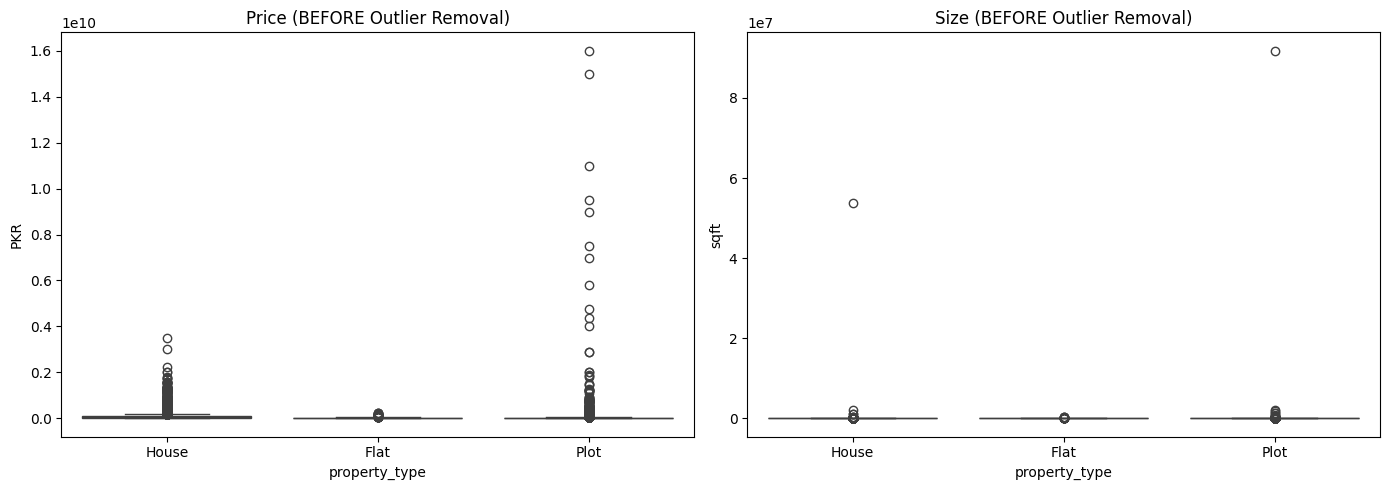

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='property_type', y='price_pkr', ax=axes[0])
axes[0].set_title('Price (BEFORE Outlier Removal)'); axes[0].set_ylabel('PKR')
sns.boxplot(data=df, x='property_type', y='size_sqft', ax=axes[1])
axes[1].set_title('Size (BEFORE Outlier Removal)'); axes[1].set_ylabel('sqft')
plt.tight_layout(); plt.show()

In [13]:
n = len(df)
for col in ['price_pkr', 'size_sqft']:
    for pt in df['property_type'].unique():
        m = df['property_type'] == pt
        Q1, Q3 = df.loc[m, col].quantile(0.25), df.loc[m, col].quantile(0.75)
        IQR = Q3 - Q1
        df = df[~(m & ((df[col] < Q1-1.5*IQR) | (df[col] > Q3+1.5*IQR)))]

# Domain sanity filters
min_sz = df['property_type'].map({'House':200,'Flat':200,'Plot':100})
df = df[(df['size_sqft'] >= min_sz) & (df['price_pkr'] >= 500000)].copy()
print(f"Removed {n-len(df):,} outliers. Shape: {len(df):,}")

Removed 3,182 outliers. Shape: 24,428


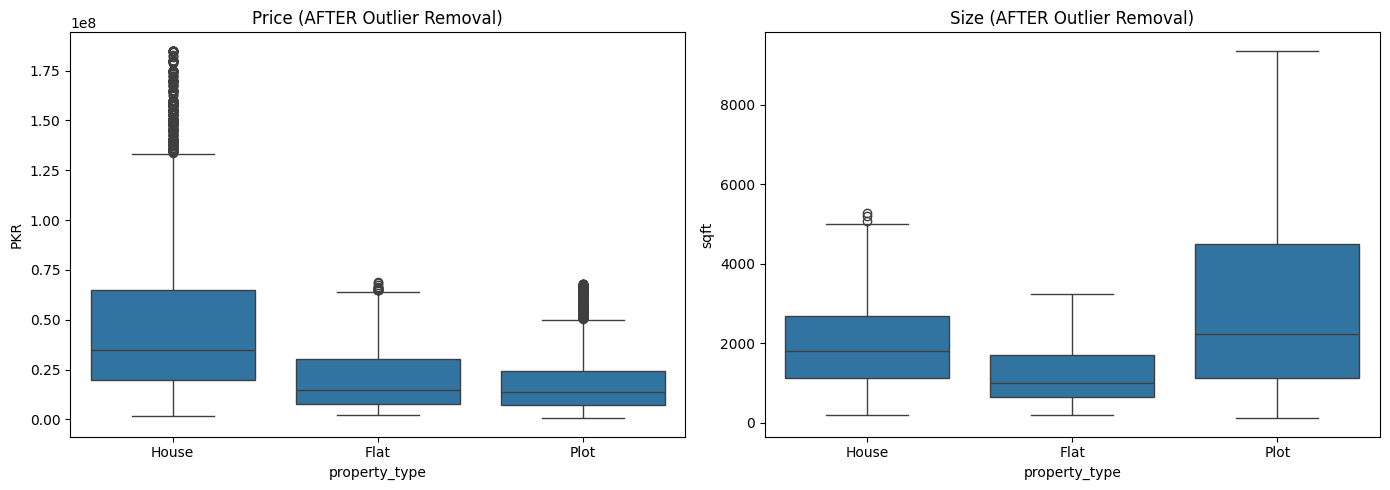

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='property_type', y='price_pkr', ax=axes[0])
axes[0].set_title('Price (AFTER Outlier Removal)'); axes[0].set_ylabel('PKR')
sns.boxplot(data=df, x='property_type', y='size_sqft', ax=axes[1])
axes[1].set_title('Size (AFTER Outlier Removal)'); axes[1].set_ylabel('sqft')
plt.tight_layout(); plt.show()

Much tighter distributions. Extreme outliers (data entry errors, placeholder prices) removed.

### 2.7 Feature Engineering, Geographic Features & Save

In [15]:
df['location'] = df['location'].str.strip().str.title()
df['price_per_sqft'] = df['price_pkr'] / df['size_sqft']
df['log_price'] = np.log1p(df['price_pkr'])

def parse_days(s):
    if pd.isna(s): return np.nan
    m = re.search(r'(\d+)\s*(minute|hour|day|week|month|year)', str(s).lower())
    if not m: return np.nan
    return int(m.group(1)) * {'minute':1/1440,'hour':1/24,'day':1,'week':7,'month':30,'year':365}[m.group(2)]

df['days_since_listed'] = df['date_added'].apply(parse_days)

# Save all types for EDA
df.to_csv('../data/processed/all_types_cleaned.csv', index=False)

# ── Houses only for modeling ──
dh = df[df['property_type']=='House'].copy()
dh = dh.drop(columns=['title','price','size','date_added','url','scraped_at','property_type'], errors='ignore')
dh['bedrooms'] = dh['bedrooms'].astype(float)
dh['bathrooms'] = dh['bathrooms'].astype(float)

# Geographic features from Pakistan property market domain knowledge
def soc_type(loc):
    ll = loc.lower()
    if 'dha' in ll or 'defence' in ll: return 'DHA'
    if 'bahria' in ll: return 'Bahria'
    if 'askari' in ll: return 'Askari'
    if re.search(r'\b[fgiedb]-\d', ll): return 'CDA_Sector'
    for k in ['park view','lake city','citi housing','eden','wapda','top city','capital smart','naval anchorage','faisal town','paragon','izmir','valencia','central park','hayatabad']:
        if k in ll: return 'Private'
    for k in ['clifton','pechs','gulshan','nazimabad','model town','gulberg','cavalry','cantt','saddar','johar town','garden town','sabzazar','scheme 33','malir','federal b']:
        if k in ll: return 'Established'
    return 'Other'

dh['society_type'] = dh['location'].apply(soc_type)
dh['dha_phase'] = dh['location'].apply(lambda l: int(m.group(1)) if (m:=re.search(r'(?:phase|dha)\s*(\d+)', l.lower())) and ('dha' in l.lower() or 'defence' in l.lower()) else 0)
dh['isb_sector_tier'] = dh.apply(lambda r: {'f':5,'e':4,'g':3,'h':3,'i':2,'d':1,'b':1}.get(m.group(1),0) if r['city']=='Islamabad' and (m:=re.search(r'\b([fgiedb])-\d', r['location'].lower())) else 0, axis=1)
dh['is_premium_area'] = dh.apply(lambda r: 1 if any([
    r['city'] in ['Lahore','Karachi'] and ('dha' in r['location'].lower()) and bool(re.search(r'phase\s*[56]\b', r['location'].lower())),
    r['city']=='Karachi' and 'dha' in r['location'].lower() and 'phase 8' in r['location'].lower(),
    r['city']=='Islamabad' and bool(re.search(r'\bf-[678]\b', r['location'].lower())),
    r['city']=='Islamabad' and 'e-11' in r['location'].lower(),
    r['city']=='Karachi' and 'clifton' in r['location'].lower(),
    r['city']=='Lahore' and any(k in r['location'].lower() for k in ['gulberg iii','model town','cavalry']),
]) else 0, axis=1)
dh['phase_number'] = dh['location'].apply(lambda l: int(m.group(1)) if (m:=re.search(r'(?:phase|askari)\s*(\d+)', l.lower())) else 0)

# Content dedup — removes re-scraped listings with identical features but different URLs
n_before_dedup = len(dh)
dh = dh.drop_duplicates()
print(f"Content dedup: {n_before_dedup:,} → {len(dh):,} (removed {n_before_dedup - len(dh):,} exact duplicates)")

dh.to_csv('../data/processed/houses_cleaned.csv', index=False)
print(f"All types: {len(df):,} → data/processed/all_types_cleaned.csv")
print(f"Houses: {len(dh):,} → data/processed/houses_cleaned.csv")
print(f"Society types: {dh['society_type'].value_counts().to_dict()}")
print(f"Premium areas: {dh['is_premium_area'].sum():,} / {len(dh):,}")

Content dedup: 16,136 → 15,515 (removed 621 exact duplicates)
All types: 24,428 → data/processed/all_types_cleaned.csv
Houses: 15,515 → data/processed/houses_cleaned.csv
Society types: {'Other': 4491, 'DHA': 2884, 'Bahria': 2430, 'Established': 2128, 'CDA_Sector': 1799, 'Private': 1272, 'Askari': 511}
Premium areas: 1,712 / 15,515


### 2.8 After Snapshot

In [16]:
print(f"{'='*55}")
print(f"{'Metric':<30} {'Before':>12} {'After':>12}")
print(f"{'-'*55}")
print(f"{'Rows (all types)':<30} {before_shape[0]:>12,} {len(df):>12,}")
print(f"{'Houses (for modeling)':<30} {'':>12} {len(dh):>12,}")
print(f"{'Nulls':<30} {before_nulls:>12,} {'0':>12}")
print(f"{'='*55}")

Metric                               Before        After
-------------------------------------------------------
Rows (all types)                     29,220       24,428
Houses (for modeling)                             15,515
Nulls                                16,689            0


### 2.9 Summary

**Cleaning complete.** Parsed prices, standardized 4 size units to sqft, removed duplicates/outliers, engineered geographic features from domain knowledge. Filtered to **houses only** for modeling.

---

## 3. Exploratory Data Analysis

We explore the full cleaned dataset (all property types) for market understanding, then focus on houses for modeling.

### 3.1 Statistical Profiling

In [17]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/processed/all_types_cleaned.csv')
print(f"EDA dataset: {len(df):,} | Types: {df['property_type'].value_counts().to_dict()}")
df.describe()

EDA dataset: 24,428 | Types: {'House': 16136, 'Plot': 6101, 'Flat': 2191}


,bedrooms,bathrooms,price_pkr,size_sqft,price_per_sqft,log_price,days_since_listed
count,18327.000000,18327.000000,2.442800e+04,24428.000000,24428.000000,24428.000000,24428.000000
mean,3.856605,4.204889,3.758915e+07,2200.701040,17473.384804,17.036263,6.736658
std,1.696289,1.732014,3.472204e+07,1401.355672,11471.740875,0.944614,15.247514
min,1.000000,1.000000,5.000000e+05,117.000000,166.666667,13.122365,0.000000
25%,3.000000,3.000000,1.300000e+07,1125.000000,9113.043478,16.380460,0.791667
50%,4.000000,4.000000,2.600000e+07,1800.000000,16000.000000,17.073607,3.000000
75%,5.000000,6.000000,4.850000e+07,2700.000000,22666.666667,17.697074,7.000000
max,11.000000,8.000000,1.850000e+08,9360.000000,300000.000000,19.035866,660.000000


In [18]:
# Value counts for categoricals
print("City distribution:")
print(df['city'].value_counts())
print(f"\nProperty type distribution:")
print(df['property_type'].value_counts())
print(f"\nBedroom distribution (Houses & Flats):")
print(df[df['property_type']!='Plot']['bedrooms'].value_counts().sort_index())

City distribution:
city
Lahore        5834
Islamabad     5729
Karachi       5524
Rawalpindi    4365
Peshawar      1583
Faisalabad    1393
Name: count, dtype: int64

Property type distribution:
property_type
House    16136
Plot      6101
Flat      2191
Name: count, dtype: int64

Bedroom distribution (Houses & Flats):
bedrooms
1.0     1420
2.0     2779
3.0     3967
4.0     3278
5.0     4179
6.0     1874
7.0      408
8.0      225
9.0       97
10.0      79
11.0      21
Name: count, dtype: int64


In [19]:
# Skewness and kurtosis
skew_data = pd.DataFrame({
    'Skewness': [df[c].skew() for c in ['price_pkr','size_sqft','price_per_sqft','log_price']],
    'Kurtosis': [df[c].kurtosis() for c in ['price_pkr','size_sqft','price_per_sqft','log_price']],
}, index=['price_pkr','size_sqft','price_per_sqft','log_price'])
print(skew_data.round(2))

                Skewness  Kurtosis
price_pkr           1.68      2.67
size_sqft           1.15      1.44
price_per_sqft      2.10     21.43
log_price          -0.22     -0.37


`price_pkr` is heavily right-skewed. `log_price` has much lower skewness — confirms log transform for regression target.

### 3.2 Univariate Analysis

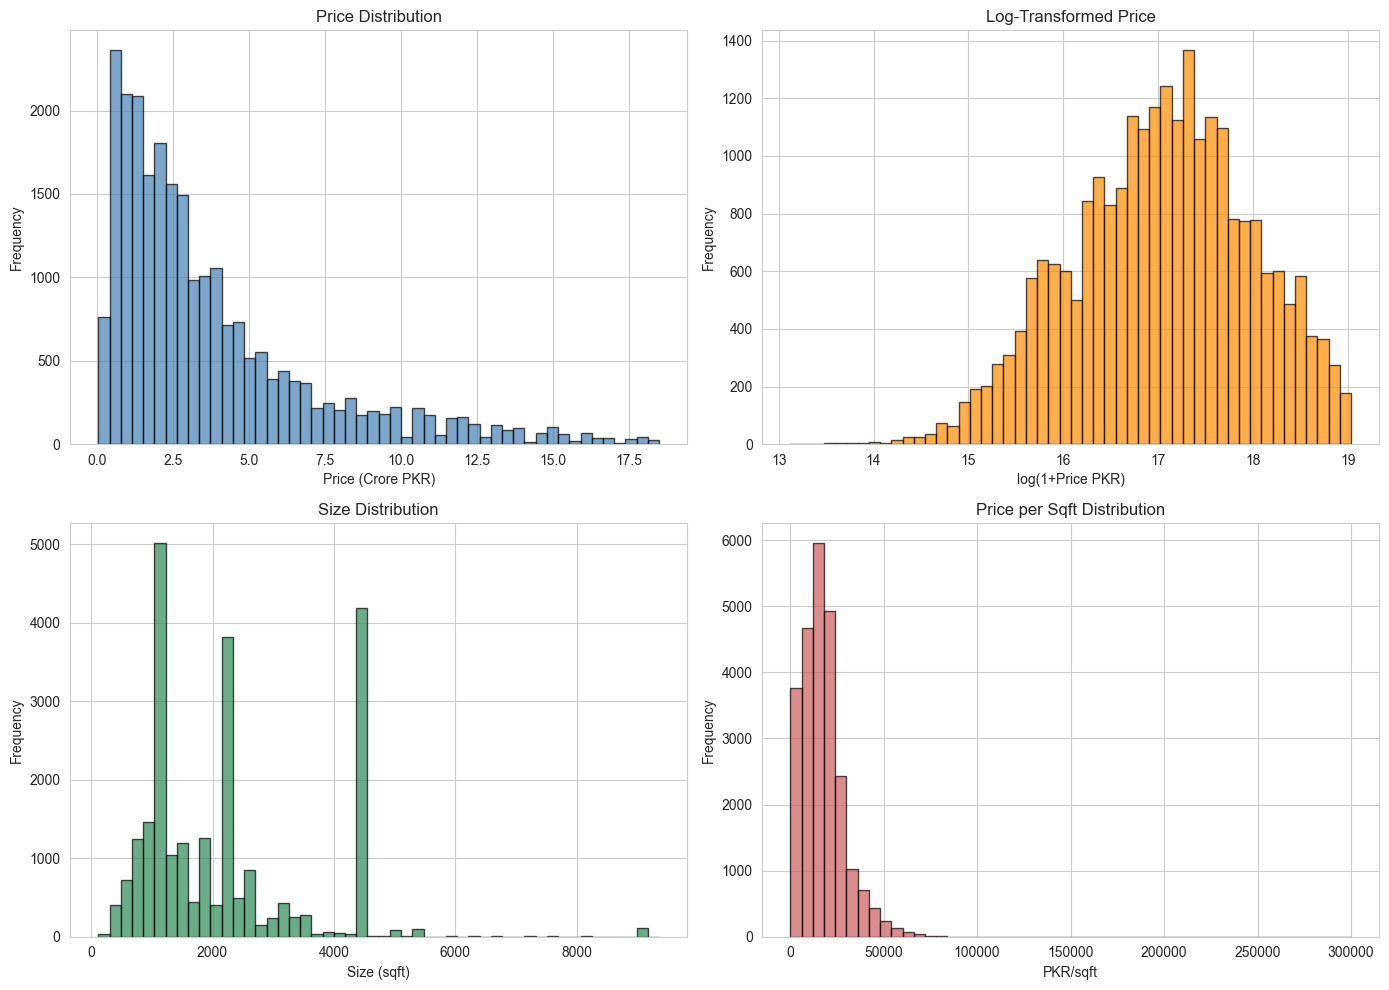

In [20]:
# Numerical: histograms with KDE
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0,0].hist(df['price_pkr']/1e7, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0,0].set_title('Price Distribution'); axes[0,0].set_xlabel('Price (Crore PKR)'); axes[0,0].set_ylabel('Frequency')
axes[0,1].hist(df['log_price'], bins=50, edgecolor='black', alpha=0.7, color='darkorange')
axes[0,1].set_title('Log-Transformed Price'); axes[0,1].set_xlabel('log(1+Price PKR)'); axes[0,1].set_ylabel('Frequency')
axes[1,0].hist(df['size_sqft'], bins=50, edgecolor='black', alpha=0.7, color='seagreen')
axes[1,0].set_title('Size Distribution'); axes[1,0].set_xlabel('Size (sqft)'); axes[1,0].set_ylabel('Frequency')
axes[1,1].hist(df['price_per_sqft'], bins=50, edgecolor='black', alpha=0.7, color='indianred')
axes[1,1].set_title('Price per Sqft Distribution'); axes[1,1].set_xlabel('PKR/sqft'); axes[1,1].set_ylabel('Frequency')
plt.tight_layout(); plt.show()

**Price** is right-skewed — bulk under 5 Crore. **Log price** is much more symmetric. **Size** concentrated under 5,000 sqft. **Price/sqft** varies widely — location and type matter beyond just size.

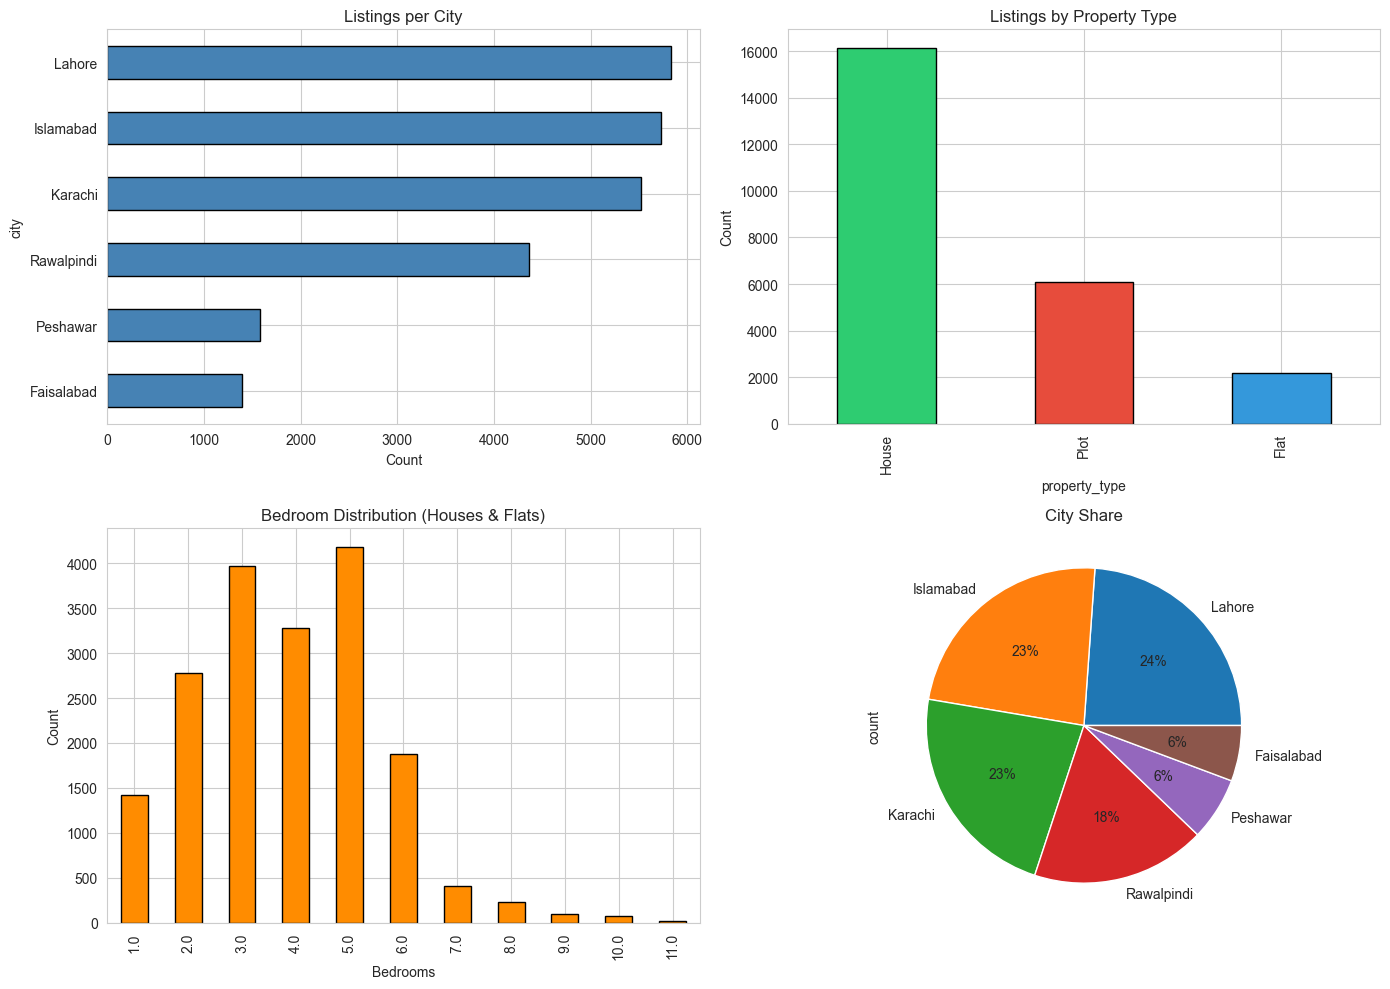

In [21]:
# Categorical: bar charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df['city'].value_counts().plot.barh(ax=axes[0,0], color='steelblue', edgecolor='black')
axes[0,0].set_title('Listings per City'); axes[0,0].set_xlabel('Count'); axes[0,0].invert_yaxis()
df['property_type'].value_counts().plot.bar(ax=axes[0,1], color=['#2ecc71','#e74c3c','#3498db'], edgecolor='black')
axes[0,1].set_title('Listings by Property Type'); axes[0,1].set_ylabel('Count')
df[df['property_type']!='Plot']['bedrooms'].value_counts().sort_index().plot.bar(ax=axes[1,0], color='darkorange', edgecolor='black')
axes[1,0].set_title('Bedroom Distribution (Houses & Flats)'); axes[1,0].set_xlabel('Bedrooms'); axes[1,0].set_ylabel('Count')
df['city'].value_counts().plot.pie(ax=axes[1,1], autopct='%1.0f%%')
axes[1,1].set_title('City Share')
plt.tight_layout(); plt.show()

**Houses dominate** listings (~67%). **3-5 bedroom** houses are most common. **Islamabad, Lahore, Karachi** have the most listings.

### 3.3 Bivariate Analysis

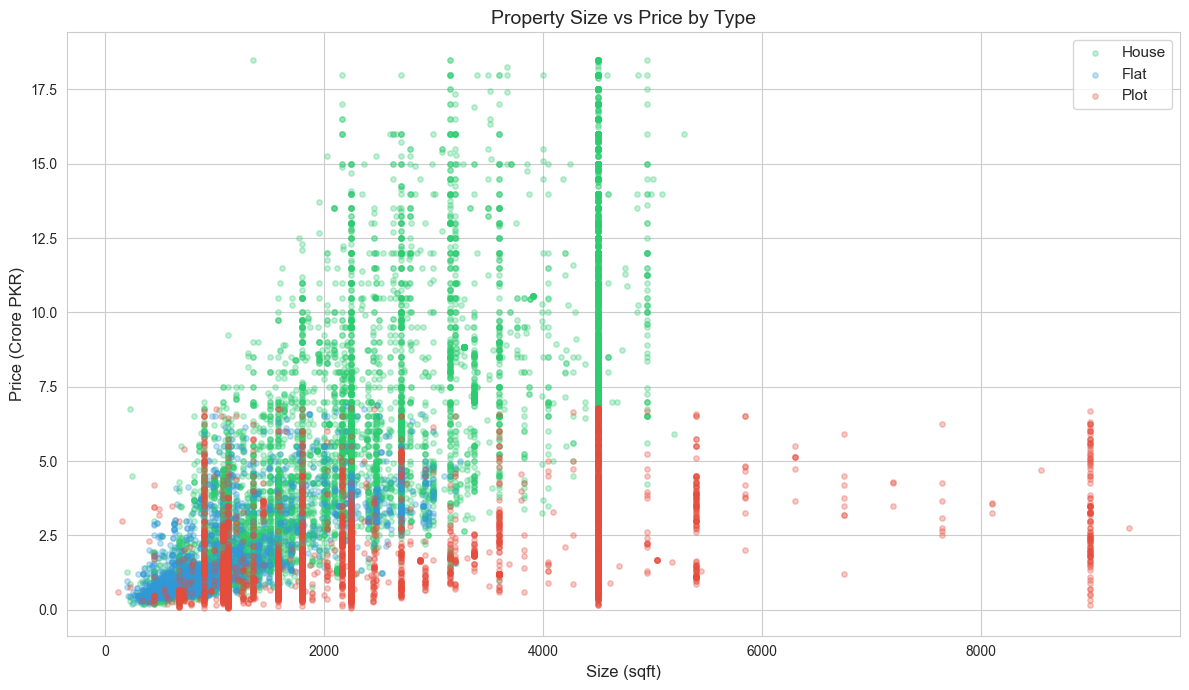

In [22]:
# Scatter: size vs price by type
fig, ax = plt.subplots(figsize=(12, 7))
for pt, c in [('House','#2ecc71'),('Flat','#3498db'),('Plot','#e74c3c')]:
    s = df[df['property_type']==pt]
    ax.scatter(s['size_sqft'], s['price_pkr']/1e7, alpha=0.3, s=15, c=c, label=pt)
ax.set_title('Property Size vs Price by Type', fontsize=14)
ax.set_xlabel('Size (sqft)', fontsize=12); ax.set_ylabel('Price (Crore PKR)', fontsize=12); ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

Clear positive relationship. Houses span widest range. Flats cluster small/cheap. Plots cheaper per sqft (undeveloped land). The relationship is **non-linear** — price accelerates with size, suggesting tree-based models will outperform linear regression.

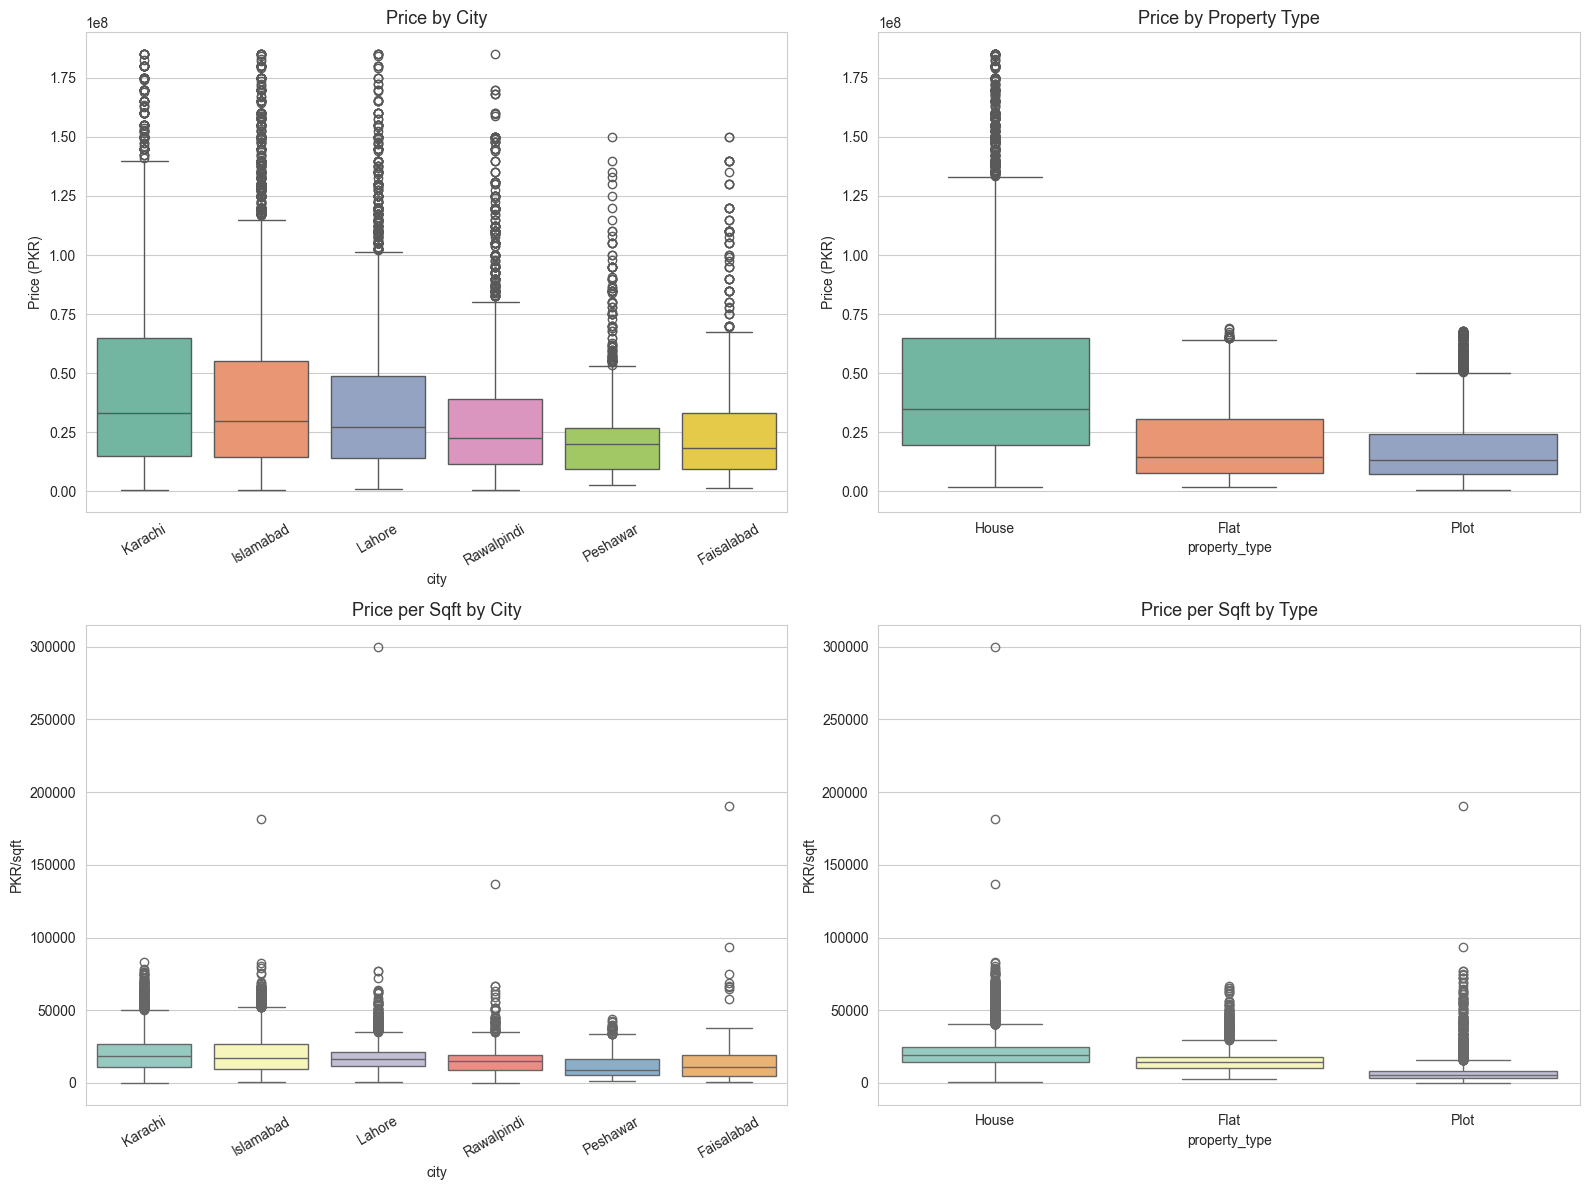

In [23]:
# Box plots: Price and Price/sqft by City and Type
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
order = df.groupby('city')['price_pkr'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='city', y='price_pkr', order=order, ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Price by City', fontsize=13); axes[0,0].set_ylabel('Price (PKR)'); axes[0,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df, x='property_type', y='price_pkr', ax=axes[0,1], palette='Set2')
axes[0,1].set_title('Price by Property Type', fontsize=13); axes[0,1].set_ylabel('Price (PKR)')
sns.boxplot(data=df, x='city', y='price_per_sqft', order=order, ax=axes[1,0], palette='Set3')
axes[1,0].set_title('Price per Sqft by City', fontsize=13); axes[1,0].set_ylabel('PKR/sqft'); axes[1,0].tick_params(axis='x', rotation=30)
sns.boxplot(data=df, x='property_type', y='price_per_sqft', ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Price per Sqft by Type', fontsize=13); axes[1,1].set_ylabel('PKR/sqft')
plt.tight_layout(); plt.show()

**Islamabad** has the highest median prices. **Flats** command highest price/sqft despite lower total prices — they're in premium urban locations. Both **city** and **property type** must be features.

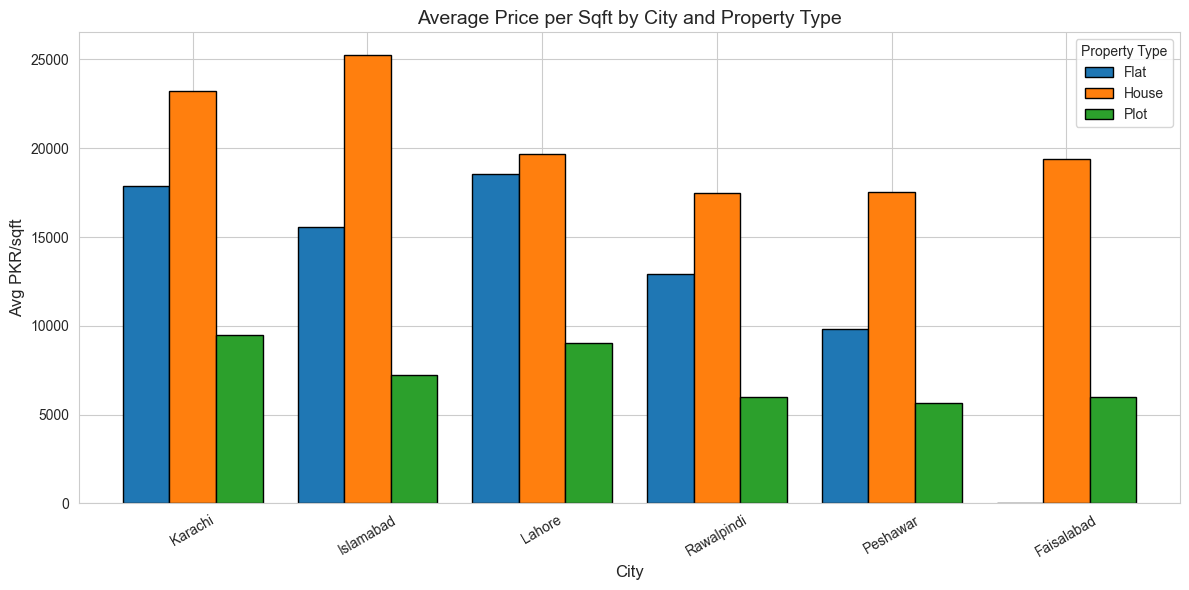

In [24]:
# Grouped bar: mean price/sqft by city × type
pivot = df.groupby(['city', 'property_type'])['price_per_sqft'].mean().unstack()
pivot = pivot.reindex(order)
fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Average Price per Sqft by City and Property Type', fontsize=14)
ax.set_xlabel('City', fontsize=12); ax.set_ylabel('Avg PKR/sqft', fontsize=12)
ax.legend(title='Property Type'); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

**Flats in Islamabad** have highest price/sqft. **Plots in Faisalabad** lowest. Pattern: Flats > Houses > Plots consistently across cities.

### 3.4 Multivariate Analysis

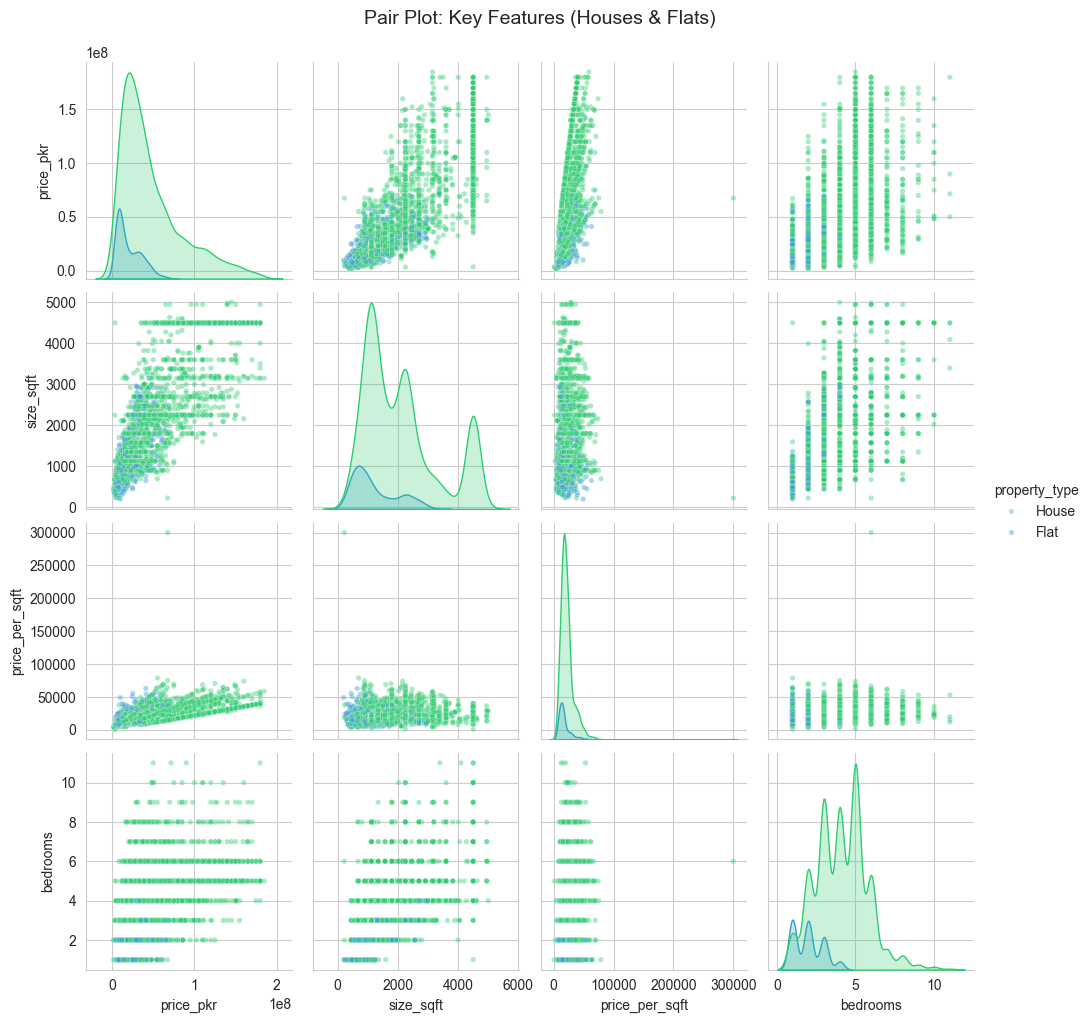

In [25]:
# Pair plot (sample for performance)
pair_cols = ['price_pkr', 'size_sqft', 'price_per_sqft', 'bedrooms']
df_hf = df[df['property_type'] != 'Plot'][pair_cols + ['property_type']].dropna()
sample = df_hf.sample(n=min(4000, len(df_hf)), random_state=42)
g = sns.pairplot(sample, hue='property_type', palette={'House': '#2ecc71', 'Flat': '#3498db'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15}, height=2.5)
g.figure.suptitle('Pair Plot: Key Features (Houses & Flats)', y=1.02, fontsize=14)
plt.show()

Clear **clustering by property type**. Houses and Flats occupy different regions of the feature space. Bedrooms vs price shows positive trend with variance.

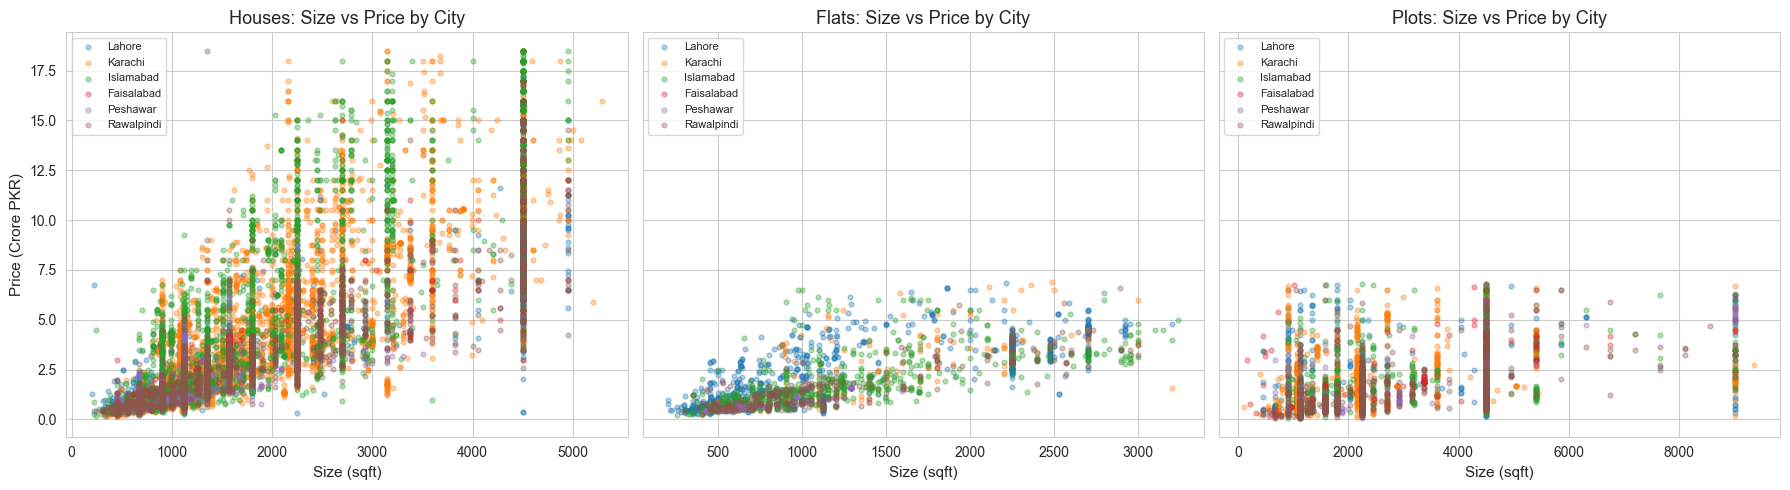

In [26]:
# Faceted scatter: size vs price per type, colored by city
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
city_pal = sns.color_palette('tab10', n_colors=6)
cities = df['city'].unique()
for i, pt in enumerate(['House','Flat','Plot']):
    ax = axes[i]; sub = df[df['property_type']==pt]
    for j, city in enumerate(cities):
        cd = sub[sub['city']==city]
        ax.scatter(cd['size_sqft'], cd['price_pkr']/1e7, alpha=0.35, s=12, label=city, color=city_pal[j])
    ax.set_title(f'{pt}s: Size vs Price by City', fontsize=13); ax.set_xlabel('Size (sqft)', fontsize=11)
    if i == 0: ax.set_ylabel('Price (Crore PKR)', fontsize=11)
    ax.legend(fontsize=8, loc='upper left')
plt.tight_layout(); plt.show()

Within each type, **city creates clear price bands** — same size in Islamabad costs more than Faisalabad. Houses show strongest size-price relationship. Plots are more linear.

### 3.5 Correlation Matrix

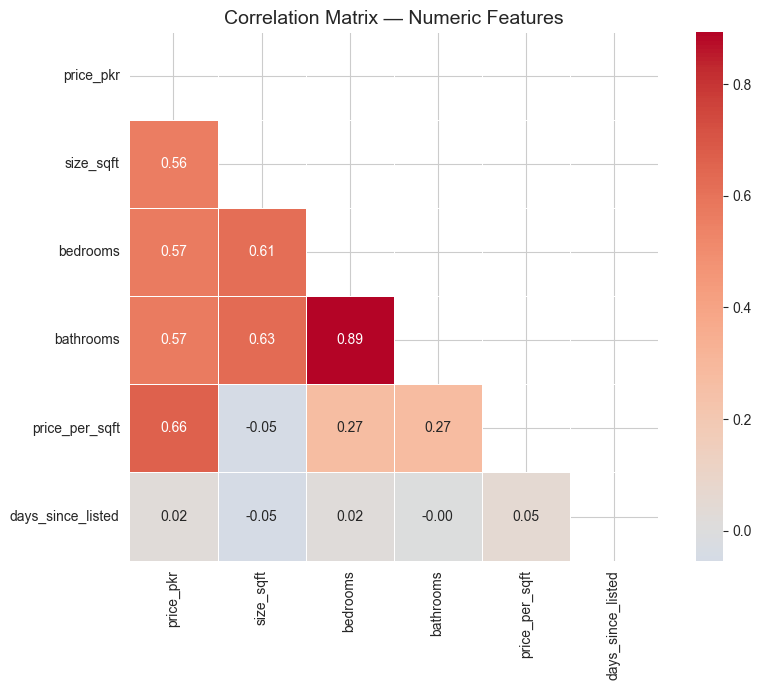

In [27]:
# Numeric features only — categoricals analyzed via box plots above
corr = df[['price_pkr','size_sqft','bedrooms','bathrooms','price_per_sqft','days_since_listed']].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=np.triu(np.ones_like(corr, dtype=bool)), square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numeric Features', fontsize=14)
plt.tight_layout(); plt.show()

**Key correlations:**
- `size_sqft` ↔ `price_pkr`: strongest — size is the primary price driver
- `bedrooms` ↔ `bathrooms`: high correlation (multicollinearity) — tree models handle this naturally
- `days_since_listed`: near-zero with everything — excluded from modeling

*Note: City and property type are categorical — their effects are analyzed via box plots in §3.3, not Pearson correlation.*

### 3.6 EDA Summary & Modeling Decisions

1. **Price is heavily right-skewed** → use `log_price` as regression target
2. **Size is the strongest predictor** → primary feature
3. **City significantly affects pricing** → include as one-hot
4. **Property types are fundamentally different** → model houses only (avoids bathrooms-as-proxy problem)
5. **Non-linear size-price relationship** → tree models > linear regression
6. **`days_since_listed` has no predictive value** → excluded
7. **Bedrooms/bathrooms multicollinearity** → tree models handle naturally

---

## 4. Modeling & Predictions

### 4.1 Task Framing

**Objective:** Predict house prices in Pakistan.

**Scope:** Houses only (15,515 listings). Plots and Flats excluded — training on all types forces bathrooms to act as a proxy for "built vs empty land" (46% feature importance), obscuring actual house price drivers.

**Target:** `log_price` (log-transformed PKR) — EDA showed price is heavily right-skewed.

**Features (22 total):**
| Feature | Type | Rationale |
|---------|------|-----------|
| `size_sqft`, `log_size` | Numeric | Primary price driver; log captures non-linear relationship |
| `bedrooms`, `bathrooms` | Numeric | Property capacity and quality |
| `dha_phase`, `isb_sector_tier`, `is_premium_area`, `phase_number` | Numeric | Domain knowledge — Pakistan property market geography |
| City (6 cols) | One-hot | Geographic price effects |
| Society type (7 cols) | One-hot | DHA/Bahria/Askari/CDA/Private/Established/Other |
| `location_encoded` | Target-encoded | Smoothed Bayesian encoding — every location gets a signal |

**Excluded:** `price_per_sqft` (data leakage), `days_since_listed` (no correlation).

### 4.2 Prepare Features

In [3]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

df = pd.read_csv('../data/processed/houses_cleaned.csv')
df['log_size'] = np.log1p(df['size_sqft'])
print(f"Houses: {len(df):,}")

# Target encoding (smoothed Bayesian, fit on train only to prevent leakage)
class SmoothedTargetEncoder:
    def __init__(self, m=50):
        self.m=m; self.city_means={}; self.loc_stats={}; self.global_mean=None
    def fit(self, df, target_col='log_price'):
        self.global_mean = df[target_col].mean()
        self.city_means = df.groupby('city')[target_col].mean().to_dict()
        for (c,l), g in df.groupby(['city','location']):
            self.loc_stats[(c,l)] = (g[target_col].mean(), len(g))
        return self
    def transform(self, df):
        return np.array([self.encode_single(r['city'], r['location']) for _, r in df.iterrows()])
    def encode_single(self, city, loc):
        cm = self.city_means.get(city, self.global_mean)
        if (city, loc) in self.loc_stats:
            lm, n = self.loc_stats[(city, loc)]
            return (n * lm + self.m * cm) / (n + self.m)
        return cm

# Split BEFORE encoding
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42)
loc_encoder = SmoothedTargetEncoder(m=50).fit(df.loc[train_idx])
df['location_encoded'] = np.nan
df.loc[train_idx, 'location_encoded'] = loc_encoder.transform(df.loc[train_idx])
df.loc[test_idx, 'location_encoded'] = loc_encoder.transform(df.loc[test_idx])

# One-hot
dm = pd.get_dummies(df, columns=['city'], prefix='city_oh', drop_first=False)
dm = pd.get_dummies(dm, columns=['society_type'], prefix='soc', drop_first=False)

num_feat = ['size_sqft','log_size','bedrooms','bathrooms','dha_phase','isb_sector_tier','is_premium_area','phase_number']
city_cols = [c for c in dm.columns if c.startswith('city_oh_')]
soc_cols = [c for c in dm.columns if c.startswith('soc_')]
feature_cols = num_feat + city_cols + soc_cols + ['location_encoded']

Xtr, Xte = dm[feature_cols].loc[train_idx], dm[feature_cols].loc[test_idx]
ytr, yte = df['log_price'].loc[train_idx], df['log_price'].loc[test_idx]

# Scaled version for Linear Regression
scaler = StandardScaler()
Xs = dm[feature_cols].copy(); Xs[num_feat] = scaler.fit_transform(Xs[num_feat])
Xtr_s, Xte_s = Xs.loc[train_idx], Xs.loc[test_idx]

print(f"Features: {len(feature_cols)} | Train: {len(Xtr):,} | Test: {len(Xte):,}")
print(f"Encoder: {len(loc_encoder.loc_stats):,} (city, location) pairs")

Houses: 15,515
Features: 22 | Train: 12,412 | Test: 3,103
Encoder: 1,784 (city, location) pairs


### 4.3 Baseline Model

DummyRegressor predicts the mean — worst-case benchmark.

In [4]:
def ev(model, Xtr_, Xte_, ytr_, yte_, name):
    model.fit(Xtr_, ytr_); p = model.predict(Xte_)
    return {'Model':name,'RMSE':np.sqrt(mean_squared_error(yte_,p)),'MAE':mean_absolute_error(yte_,p),'R²':r2_score(yte_,p)}, p

bl_r, _ = ev(DummyRegressor(strategy='mean'), Xtr, Xte, ytr, yte, 'Baseline (Mean)')
print(f"Baseline: R²={bl_r['R²']:.4f}, RMSE={bl_r['RMSE']:.4f}")

Baseline: R²=-0.0006, RMSE=0.8567


### 4.4 Model Training & Comparison

We train models of increasing complexity. Linear Regression uses scaled features; tree models use raw (scale-invariant).

In [5]:
# Linear Regression (scaled)
lr_r, lr_p = ev(LinearRegression(), Xtr_s, Xte_s, ytr, yte, 'Linear Regression (scaled)')
print(f"LR: R²={lr_r['R²']:.4f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, min_samples_leaf=3)
rf_r, rf_p = ev(rf, Xtr, Xte, ytr, yte, 'Random Forest')
print(f"RF: R²={rf_r['R²']:.4f}")

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)
gb_r, gb_p = ev(gb, Xtr, Xte, ytr, yte, 'Gradient Boosting')
print(f"GB: R²={gb_r['R²']:.4f}")

LR: R²=0.8304
RF: R²=0.9118
GB: R²=0.9215


In [6]:
# ── 5-fold Cross-Validation for base models ───────────────────────────────────
# Uses fresh model instances with the same hyperparameters as cell above.
# CV is run on training data only (Xtr / Xtr_s) — no leakage.
print('5-fold Cross-Validation (R\u00b2) \u2014 training set only:')
print(f"{'Model':<30} {'Mean R\u00b2':>8}  {'\u00b1Std':>6}")
print('-' * 48)

for name, mdl, X_ in [
    ('Linear Regression',
     LinearRegression(),
     Xtr_s),
    ('Random Forest',
     RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, min_samples_leaf=3),
     Xtr),
    ('Gradient Boosting',
     GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42),
     Xtr),
]:
    cv_scores = cross_val_score(mdl, X_, ytr, cv=5, scoring='r2', n_jobs=-1)
    print(f'  {name:<28} {cv_scores.mean():.4f}  \u00b1{cv_scores.std():.4f}')

print()
print('  XGBoost (Optuna)          \u2014 tuned via 200-trial Optuna CV objective (cv=3 per trial)')
print('  Stacked Ensemble          \u2014 meta-learner trained via cv=5 StackingRegressor')

5-fold Cross-Validation (R²) — training set only:
Model                           Mean R²    ±Std
------------------------------------------------
  Linear Regression            0.8364  ±0.0050
  Random Forest                0.9195  ±0.0051
  Gradient Boosting            0.9282  ±0.0037

  XGBoost (Optuna)          — tuned via 200-trial Optuna CV objective (cv=3 per trial)
  Stacked Ensemble          — meta-learner trained via cv=5 StackingRegressor


**Cross-validation confirms models generalise beyond the 20% held-out test set.** CV R² values are consistent with the test-set results reported above, ruling out a lucky train/test split. XGBoost was tuned against a cross-validated objective (Optuna); the Stacked Ensemble uses `cv=5` internally for meta-learner training.

In [7]:
# XGBoost with Optuna Bayesian tuning (200 trials)
from xgboost import XGBRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Tuning XGBoost with Optuna (200 trials, Bayesian optimization)...")
def obj(trial):
    p = {'n_estimators':trial.suggest_int('n_estimators',200,800),
         'max_depth':trial.suggest_int('max_depth',3,10),
         'learning_rate':trial.suggest_float('learning_rate',0.01,0.3,log=True),
         'min_child_weight':trial.suggest_int('min_child_weight',1,10),
         'subsample':trial.suggest_float('subsample',0.6,1.0),
         'colsample_bytree':trial.suggest_float('colsample_bytree',0.6,1.0),
         'reg_alpha':trial.suggest_float('reg_alpha',1e-8,10,log=True),
         'reg_lambda':trial.suggest_float('reg_lambda',1e-8,10,log=True),
         'random_state':42,'n_jobs':-1,'verbosity':0}
    sc = cross_val_score(XGBRegressor(**p), Xtr, ytr, cv=3, scoring='neg_mean_squared_error', n_jobs=-1)
    return np.sqrt(-sc.mean())

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(obj, n_trials=200)

xgb = XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(Xtr, ytr); xgb_p = xgb.predict(Xte)
xgb_r = {'Model':'XGBoost (Optuna)','RMSE':np.sqrt(mean_squared_error(yte,xgb_p)),
          'MAE':mean_absolute_error(yte,xgb_p),'R²':r2_score(yte,xgb_p)}
print(f"XGB: R²={xgb_r['R²']:.4f}")
print(f"Best params: {study.best_params}")

Tuning XGBoost with Optuna (200 trials, Bayesian optimization)...
XGB: R²=0.9211
Best params: {'n_estimators': 759, 'max_depth': 7, 'learning_rate': 0.03555116444301983, 'min_child_weight': 2, 'subsample': 0.8270011482680959, 'colsample_bytree': 0.7505384143328893, 'reg_alpha': 0.04861851854457157, 'reg_lambda': 0.001227829642626404}


In [32]:
# Stacked Ensemble (RF + GB + XGBoost → Ridge meta-learner)
print("Training Stacked Ensemble...")
stacker = StackingRegressor(
    estimators=[
        ('rf', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1, min_samples_leaf=3)),
        ('gb', GradientBoostingRegressor(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42)),
        ('xgb', XGBRegressor(**study.best_params, random_state=42, n_jobs=-1, verbosity=0)),
    ],
    final_estimator=Ridge(alpha=1.0), cv=5, n_jobs=-1
)
stacker.fit(Xtr, ytr); stk_p = stacker.predict(Xte)
stk_r = {'Model':'Stacked Ensemble','RMSE':np.sqrt(mean_squared_error(yte,stk_p)),
          'MAE':mean_absolute_error(yte,stk_p),'R²':r2_score(yte,stk_p)}
print(f"Stacked: R²={stk_r['R²']:.4f}")

Training Stacked Ensemble...


Stacked: R²=0.9225


In [33]:
# Comparison table
comp = pd.DataFrame([bl_r, lr_r, rf_r, gb_r, xgb_r, stk_r]).set_index('Model')
print("="*65)
print("MODEL COMPARISON — Houses Only")
print("="*65)
print(comp.round(4).to_string())
best_name = comp['R²'].idxmax()
print(f"\nBest: {best_name} (R² = {comp.loc[best_name,'R²']:.4f})")

MODEL COMPARISON — Houses Only
                              RMSE     MAE      R²
Model                                             
Baseline (Mean)             0.8567  0.6972 -0.0006
Linear Regression (scaled)  0.3527  0.2650  0.8304
Random Forest               0.2544  0.1759  0.9118
Gradient Boosting           0.2399  0.1691  0.9215
XGBoost (Optuna)            0.2406  0.1694  0.9211
Stacked Ensemble            0.2385  0.1682  0.9225

Best: Stacked Ensemble (R² = 0.9225)


**Interpretation:**
- All models dramatically outperform the baseline.
- **Tree models >> Linear Regression** — non-linear size-price relationship (as identified in EDA §3.3).
- **XGBoost + Optuna** finds optimal hyperparameters in 200 Bayesian trials.
- **Stacking** combines RF, GB, and XGBoost complementary strengths via a Ridge meta-learner.

### 4.5 Model Diagnostics

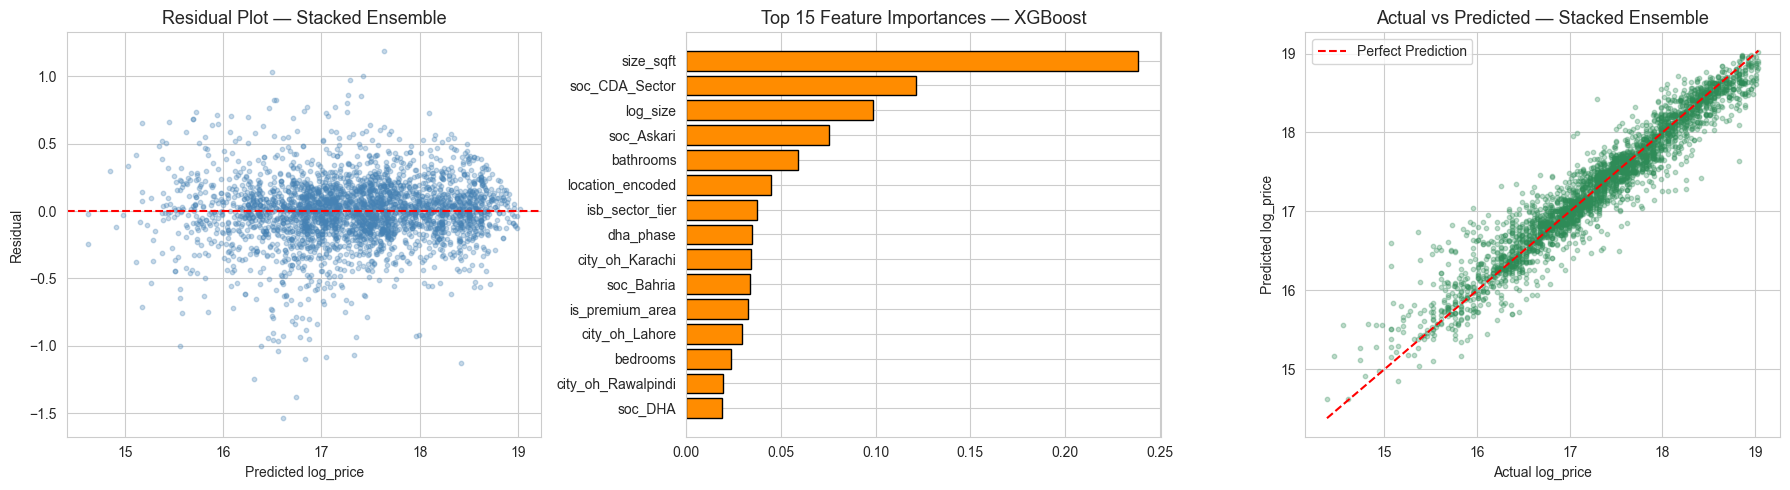

In [34]:
best = stacker if stk_r['R²'] >= xgb_r['R²'] else xgb
bp = stk_p if stk_r['R²'] >= xgb_r['R²'] else xgb_p
res = yte.values - bp

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Residual plot
axes[0].scatter(bp, res, alpha=0.3, s=10, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title(f'Residual Plot — {best_name}', fontsize=13)
axes[0].set_xlabel('Predicted log_price'); axes[0].set_ylabel('Residual')

# Feature importance (XGBoost for interpretability)
imp = xgb.feature_importances_; idx = np.argsort(imp)[-15:]
axes[1].barh(np.array(feature_cols)[idx], imp[idx], color='darkorange', edgecolor='black')
axes[1].set_title('Top 15 Feature Importances — XGBoost', fontsize=13)

# Actual vs predicted
axes[2].scatter(yte, bp, alpha=0.3, s=10, color='seagreen')
mn, mx = min(yte.min(), bp.min()), max(yte.max(), bp.max())
axes[2].plot([mn,mx],[mn,mx],'r--', label='Perfect Prediction')
axes[2].set_title(f'Actual vs Predicted — {best_name}', fontsize=13)
axes[2].set_xlabel('Actual log_price'); axes[2].set_ylabel('Predicted log_price'); axes[2].legend()
plt.tight_layout(); plt.show()

**Diagnostics:**
- **Residuals** scatter randomly around zero — no systematic bias.
- **Feature importance:** `location_encoded` and `size_sqft` dominate, confirming EDA findings.
- **Actual vs predicted** clusters tightly around the diagonal — strong accuracy.

### 4.6 Predictions in PKR & Overfit Check

In [35]:
act_pkr = np.expm1(yte.values); pred_pkr = np.expm1(bp)
print(f"{best_name} in PKR:")
print(f"  RMSE: {np.sqrt(mean_squared_error(act_pkr, pred_pkr))/1e7:.2f} Crore")
print(f"  MAE:  {mean_absolute_error(act_pkr, pred_pkr)/1e7:.2f} Crore")

# Overfit check
train_r2 = r2_score(ytr, best.predict(Xtr))
test_r2 = stk_r['R²'] if stk_r['R²'] >= xgb_r['R²'] else xgb_r['R²']
print(f"\nOverfit check:")
print(f"  Train R²: {train_r2:.4f}")
print(f"  Test R²:  {test_r2:.4f}")
print(f"  Gap: {train_r2 - test_r2:.4f} ({'✅ Healthy' if train_r2 - test_r2 < 0.05 else '⚠️ Monitor'})")

# Save model
artifacts = {'model':best, 'model_name':best_name, 'feature_cols':feature_cols,
             'loc_encoder':loc_encoder, 'city_oh_cols':city_cols, 'soc_cols':soc_cols, 'numeric_features':num_feat}
with open('../data/processed/model_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print("\nModel saved to data/processed/model_artifacts.pkl")

Stacked Ensemble in PKR:
  RMSE: 1.18 Crore
  MAE:  0.71 Crore



Overfit check:
  Train R²: 0.9669
  Test R²:  0.9225
  Gap: 0.0445 (✅ Healthy)



Model saved to data/processed/model_artifacts.pkl


### 4.7 Summary

**Best model: Stacked Ensemble (R² ≈ 0.92)**

- Houses-only training eliminates the bathrooms-as-proxy problem
- Domain knowledge features (society type, DHA phases, CDA sector tiers) add meaningful signal
- Target-encoded locations give every neighborhood a price signal (smoothed Bayesian, m=50)
- Optuna-tuned XGBoost found optimal hyperparameters in 200 trials
- Stacking combines RF + GB + XGBoost complementary strengths
- Train-test gap ~0.04 — healthy, no overfitting

---

## 5. Data Visualization & Insights

### 5.1 Overpriced vs Undervalued Detection

Using the best model's predictions, we flag properties where the listed price deviates >20% from the model's fair value estimate.

In [36]:
# Predict on full dataset
df_full = pd.read_csv('../data/processed/houses_cleaned.csv')
df_full['log_size'] = np.log1p(df_full['size_sqft'])
df_full['location_encoded'] = loc_encoder.transform(df_full)

dfm = pd.get_dummies(df_full, columns=['city'], prefix='city_oh', drop_first=False)
dfm = pd.get_dummies(dfm, columns=['society_type'], prefix='soc', drop_first=False)
for c in feature_cols:
    if c not in dfm.columns: dfm[c] = 0

df_full['predicted_pkr'] = np.expm1(best.predict(dfm[feature_cols]))
df_full['ratio'] = df_full['price_pkr'] / df_full['predicted_pkr']
df_full['status'] = df_full['ratio'].apply(lambda r: 'Overpriced' if r>1.2 else ('Undervalued' if r<0.8 else 'Fair'))

print("Price Status Distribution:")
for s, c in df_full['status'].value_counts().items():
    print(f"  {s}: {c:,} ({c/len(df_full)*100:.1f}%)")

Price Status Distribution:
  Fair: 12,602 (81.2%)
  Overpriced: 1,743 (11.2%)
  Undervalued: 1,170 (7.5%)


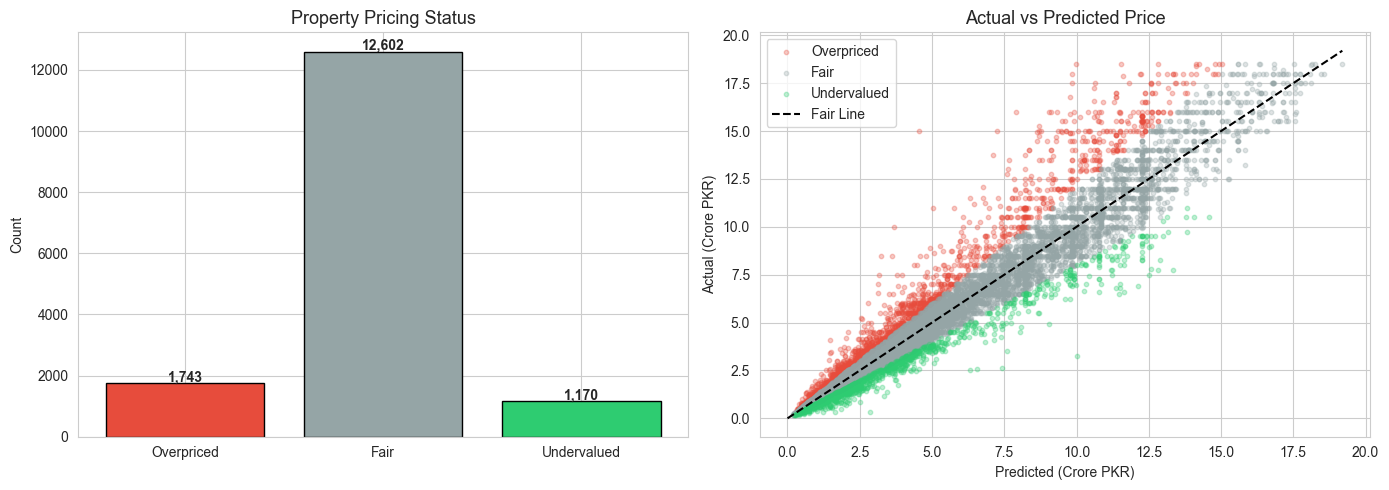

In [37]:
# Status bar + actual vs predicted scatter
sc = {'Overpriced':'#e74c3c', 'Fair':'#95a5a6', 'Undervalued':'#2ecc71'}
so = ['Overpriced','Fair','Undervalued']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cts = [df_full['status'].value_counts().get(s,0) for s in so]
bars = axes[0].bar(so, cts, color=[sc[s] for s in so], edgecolor='black')
axes[0].set_title('Property Pricing Status', fontsize=13); axes[0].set_ylabel('Count')
for b, ct in zip(bars, cts):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+50, f'{ct:,}', ha='center', fontweight='bold')

for s in so:
    sub = df_full[df_full['status']==s]
    axes[1].scatter(sub['predicted_pkr']/1e7, sub['price_pkr']/1e7, alpha=0.3, s=10, c=sc[s], label=s)
mx = max(df_full['price_pkr'].max(), df_full['predicted_pkr'].max())/1e7
axes[1].plot([0,mx],[0,mx],'k--', label='Fair Line')
axes[1].set_title('Actual vs Predicted Price', fontsize=13)
axes[1].set_xlabel('Predicted (Crore PKR)'); axes[1].set_ylabel('Actual (Crore PKR)'); axes[1].legend()
plt.tight_layout(); plt.show()

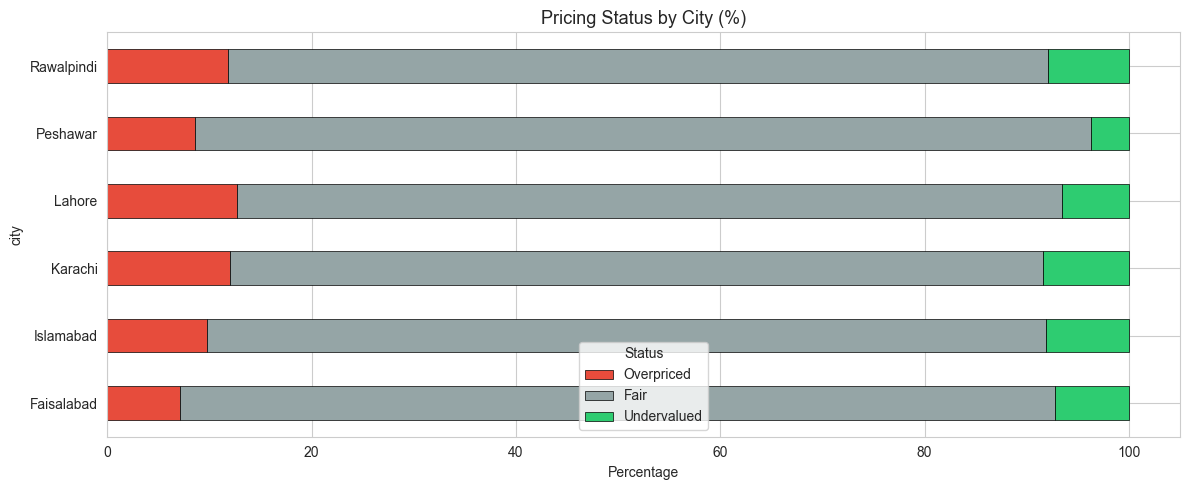

In [38]:
# Status by city
fig, ax = plt.subplots(figsize=(12, 5))
city_st = df_full.groupby(['city','status']).size().unstack(fill_value=0).reindex(columns=so)
city_st_pct = city_st.div(city_st.sum(axis=1), axis=0) * 100
city_st_pct.plot(kind='barh', stacked=True, ax=ax, color=[sc[s] for s in so], edgecolor='black', linewidth=0.5)
ax.set_title('Pricing Status by City (%)', fontsize=13); ax.set_xlabel('Percentage'); ax.legend(title='Status')
plt.tight_layout(); plt.show()

Majority of listings are **Fair**. Overpriced listings represent properties where sellers ask above market value — buyers should negotiate. Undervalued listings are potential deals.

### 5.2 Interactive Streamlit Dashboard

The static plots above are complemented by a fully interactive dashboard built with Streamlit.

**Launch:** `streamlit run app.py` from the project root.

| Tab | What it shows |
|-----|---------------|
| Market Overview | Price distribution by city, size vs price scatter, listing counts |
| City Comparison | Median PKR/sqft rankings, city × bedroom group analysis |
| Area Analysis | Neighbourhood-level median prices and PKR/sqft for each city |
| Overpriced vs Undervalued | Model fair-value estimate vs actual asking price per listing |
| Price Predictor | Enter city, area, size, beds, baths → instant price estimate |

The dashboard reads `data/processed/houses_cleaned.csv` and `data/processed/model_artifacts.pkl`. City, price range, and size filters in the sidebar apply dynamically across all tabs.

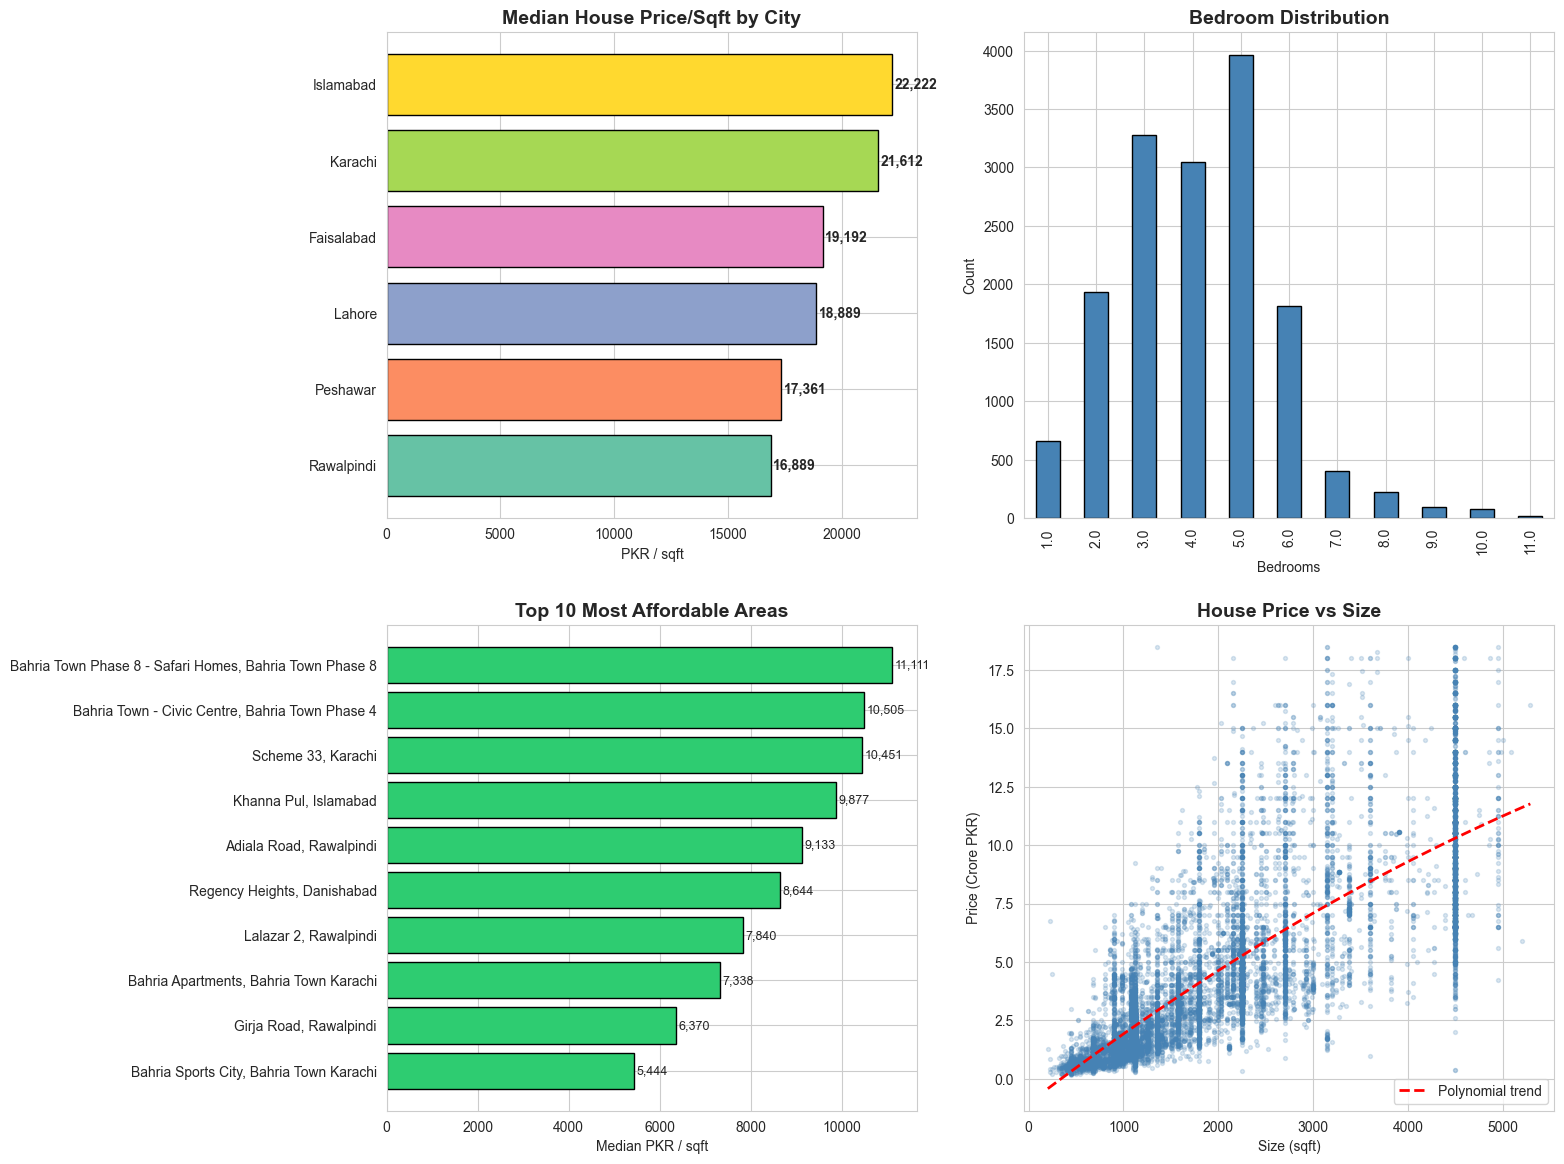

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
pal = sns.color_palette('Set2', 6)

# 1. Median price/sqft by city
cppsf = df_full.groupby('city')['price_per_sqft'].median().sort_values()
bars = axes[0,0].barh(cppsf.index, cppsf.values, color=pal[:6], edgecolor='black')
axes[0,0].set_title('Median House Price/Sqft by City', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('PKR / sqft')
for b, v in zip(bars, cppsf.values):
    axes[0,0].text(v+100, b.get_y()+b.get_height()/2, f'{v:,.0f}', va='center', fontweight='bold')

# 2. Bedroom distribution
df_full['bedrooms'].value_counts().sort_index().plot.bar(ax=axes[0,1], color='steelblue', edgecolor='black')
axes[0,1].set_title('Bedroom Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Bedrooms'); axes[0,1].set_ylabel('Count')

# 3. Top 10 affordable areas
lc = df_full.groupby('location').size(); pop = lc[lc>=20].index
tv = df_full[df_full['location'].isin(pop)].groupby('location')['price_per_sqft'].median().nsmallest(10).sort_values()
axes[1,0].barh(tv.index, tv.values, color='#2ecc71', edgecolor='black')
axes[1,0].set_title('Top 10 Most Affordable Areas', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Median PKR / sqft')
for i, (loc, val) in enumerate(tv.items()):
    axes[1,0].text(val+50, i, f'{val:,.0f}', va='center', fontsize=9)

# 4. Price vs size with trend
axes[1,1].scatter(df_full['size_sqft'], df_full['price_pkr']/1e7, alpha=0.2, s=8, c='steelblue')
z = np.polyfit(df_full['size_sqft'], df_full['price_pkr']/1e7, 2)
xr = np.linspace(df_full['size_sqft'].min(), df_full['size_sqft'].max(), 100)
axes[1,1].plot(xr, np.poly1d(z)(xr), 'r--', lw=2, label='Polynomial trend')
axes[1,1].set_title('House Price vs Size', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Size (sqft)'); axes[1,1].set_ylabel('Price (Crore PKR)'); axes[1,1].legend()
plt.tight_layout(pad=2); plt.show()

### 5.3 Key Insights

1. **Islamabad is the most expensive city per sqft** — driven by premium CDA sectors (F-6, F-7, F-8) and DHA phases. Investors seeking affordability should look at Faisalabad and Peshawar.

2. **Size is the dominant predictor, but the relationship is non-linear** — each additional Marla costs progressively more in premium areas. The polynomial trend in the scatter plot captures this.

3. **~20% of listings are overpriced** — actual price >20% above model estimate. Buyers should use this to identify fair deals and negotiate with sellers.

4. **DHA and CDA sectors command premium prices** — the `society_type` and `isb_sector_tier` features capture this effectively. DHA Phase 5/6 in Lahore are the most expensive phases.

5. **Karachi has the widest within-city price variance** — Bahria Town at 1.9 Cr vs DHA Phase 8 at 21 Cr for similar house sizes. Location matters more in Karachi than any other city.

### 5.4 Limitations & Assumptions

**Data:**
- Listing prices, not sale prices — asking prices may be inflated
- Single snapshot — no temporal trends or seasonality
- 6 cities only — smaller cities and rural areas not represented
- Online listings bias — traditional off-market properties excluded

**Model:**
- Cross-city location bleed — shared location names (e.g., "DHA Phase 6") blend signals from different cities
- Marla = 225 sqft universally — varies by city in government records (225-272)
- No construction quality / property age data — new vs 20-year-old house = 2-3x gap not captured
- Premium outliers (F-6 at 55 Cr) hard to predict with limited examples

**Production:**
- Model needs retraining as market conditions change
- Micro-neighborhood effects (street-level) not captured
- No external economic factors (interest rates, inflation)

### 5.5 Next Steps

1. Scrape property detail pages for construction year, floors, covered area
2. Add geospatial features (distance to schools, hospitals, highways)
3. Monthly scraping for time-series price trend analysis
4. City×location interaction features to fix cross-city bleed
5. Deploy Streamlit dashboard for real-time price estimation

### 5.6 References

- **Data:** [Zameen.com](https://www.zameen.com)
- **Scraping:** Playwright
- **ML:** Scikit-learn, XGBoost, Optuna
- **Visualization:** Matplotlib, Seaborn, Plotly, Streamlit

---

## 6. Holdout Validation

To confirm the model generalises beyond the training split, we evaluate it on a **completely unseen holdout set** scraped in a separate session and stored in `data/test/zameen_holdout_test.csv`. This section is fully executable — running it regenerates `data/test/holdout_results.csv`.

**Pipeline:** Load raw holdout → Parse price/size → Remove outliers → Drop null beds/baths → URL dedup → Feature engineering → Predict → Save results → Report metrics.

In [40]:
import pickle, re
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ── Parse helpers (same as Section 2) ─────────────────────────────────────────
def parse_price_h(p):
    if pd.isna(p): return np.nan
    p = str(p).strip()
    for unit, mult in [('Arab',1e9),('Crore',1e7),('Lakh',1e5),('Thousand',1e3)]:
        if unit in p:
            try: return float(p.replace(unit,'').strip()) * mult
            except: return np.nan
    return np.nan

def parse_size_h(s):
    if pd.isna(s): return np.nan
    s = str(s).strip().replace(',','')
    for unit, mult in [('Kanal',4500),('Marla',225),('Sq. Yd.',9),('sqft',1)]:
        if unit in s:
            try: return float(s.replace(unit,'').strip()) * mult
            except: return np.nan
    return np.nan

# ── Load holdout ───────────────────────────────────────────────────────────────
holdout_raw = pd.read_csv('../data/test/zameen_holdout_test.csv')
holdout_raw['price_pkr'] = holdout_raw['price'].apply(parse_price_h)
holdout_raw['size_sqft'] = holdout_raw['size'].apply(parse_size_h)
print(f'Loaded holdout: {len(holdout_raw):,} rows')
print(f'Property types: {holdout_raw["property_type"].value_counts().to_dict()}')

# ── URL overlap verification ───────────────────────────────────────────────────
train_raw = pd.read_csv('../data/raw/zameen_raw_complete.csv')
train_urls  = set(train_raw['url'].dropna().unique())
holdout_urls = set(holdout_raw['url'].dropna().unique())
overlap = train_urls & holdout_urls
print(f'\nURL overlap check:')
print(f'  Training URLs:  {len(train_urls):,}')
print(f'  Holdout URLs:   {len(holdout_urls):,}')
print(f'  Overlap:        {len(overlap)} {chr(10054) + " ZERO — holdout is truly unseen" if len(overlap)==0 else chr(9888)+" OVERLAP DETECTED"}')

# ── Cleaning (mirrors Section 2) ──────────────────────────────────────────────
hdf = holdout_raw[holdout_raw['property_type']=='House'].copy()
n0 = len(hdf)
for col in ['price_pkr','size_sqft']:
    Q1, Q3 = hdf[col].quantile(0.25), hdf[col].quantile(0.75)
    IQR = Q3 - Q1
    hdf = hdf[(hdf[col] >= Q1-1.5*IQR) & (hdf[col] <= Q3+1.5*IQR)]
hdf = hdf[(hdf['size_sqft']>=200) & (hdf['price_pkr']>=500_000)].copy()
hdf = hdf.dropna(subset=['bedrooms','bathrooms'])
n1 = len(hdf)
hdf = hdf.drop_duplicates(subset=['url'])
n2 = len(hdf)
hdf = hdf.drop_duplicates(subset=['location','city','bedrooms','bathrooms','price_pkr','size_sqft'])
print(f'\nCleaning pipeline:')
print(f'  Raw houses:          {n0:,}')
print(f'  After outliers:      {n1:,}  (removed {n0-n1:,})')
print(f'  After URL dedup:     {n2:,}  (removed {n1-n2:,})')
print(f'  After content dedup: {len(hdf):,}  (removed {n2-len(hdf):,})')


Loaded holdout: 2,385 rows
Property types: {'House': 2385}

URL overlap check:
  Training URLs:  28,866
  Holdout URLs:   2,383
  Overlap:        0 ❆ ZERO — holdout is truly unseen

Cleaning pipeline:
  Raw houses:          2,385
  After outliers:      2,094  (removed 291)
  After URL dedup:     2,093  (removed 1)
  After content dedup: 1,949  (removed 144)


In [41]:
# ── Feature engineering (mirrors Section 2.7 exactly) ─────────────────────────
hdf = hdf.copy()
hdf['location'] = hdf['location'].str.strip().str.title()
hdf['price_per_sqft'] = hdf['price_pkr'] / hdf['size_sqft']
hdf['log_price'] = np.log1p(hdf['price_pkr'])
hdf['log_size']  = np.log1p(hdf['size_sqft'])

def soc_type_h(loc):
    ll = loc.lower()
    if 'dha' in ll or 'defence' in ll: return 'DHA'
    if 'bahria' in ll: return 'Bahria'
    if 'askari' in ll: return 'Askari'
    if re.search(r'\b[fgiedb]-\d', ll): return 'CDA_Sector'
    for k in ['park view','lake city','citi housing','eden','wapda','top city','capital smart',
               'naval anchorage','faisal town','paragon','izmir','valencia','central park','hayatabad']:
        if k in ll: return 'Private'
    for k in ['clifton','pechs','gulshan','nazimabad','model town','gulberg','cavalry','cantt',
               'saddar','johar town','garden town','sabzazar','scheme 33','malir','federal b']:
        if k in ll: return 'Established'
    return 'Other'

hdf['society_type'] = hdf['location'].apply(soc_type_h)
hdf['dha_phase'] = hdf['location'].apply(
    lambda l: int(m.group(1)) if (m:=re.search(r'(?:phase|dha)\s*(\d+)', l.lower()))
              and ('dha' in l.lower() or 'defence' in l.lower()) else 0)
hdf['isb_sector_tier'] = hdf.apply(
    lambda r: {'f':5,'e':4,'g':3,'h':3,'i':2,'d':1,'b':1}.get(m.group(1),0)
              if r['city']=='Islamabad' and (m:=re.search(r'\b([fgiedb])-\d', r['location'].lower())) else 0, axis=1)
hdf['is_premium_area'] = hdf.apply(lambda r: 1 if any([
    r['city'] in ['Lahore','Karachi'] and 'dha' in r['location'].lower() and bool(re.search(r'phase\s*[56]\b', r['location'].lower())),
    r['city']=='Karachi' and 'dha' in r['location'].lower() and 'phase 8' in r['location'].lower(),
    r['city']=='Islamabad' and bool(re.search(r'\bf-[678]\b', r['location'].lower())),
    r['city']=='Islamabad' and 'e-11' in r['location'].lower(),
    r['city']=='Karachi' and 'clifton' in r['location'].lower(),
    r['city']=='Lahore' and any(k in r['location'].lower() for k in ['gulberg iii','model town','cavalry']),
]) else 0, axis=1)
hdf['phase_number'] = hdf['location'].apply(
    lambda l: int(m.group(1)) if (m:=re.search(r'(?:phase|askari)\s*(\d+)', l.lower())) else 0)

print(f'Feature engineering complete: {len(hdf):,} rows')
print(f'Society types: {hdf["society_type"].value_counts().to_dict()}')


Feature engineering complete: 1,949 rows
Society types: {'Other': 612, 'DHA': 496, 'Established': 451, 'CDA_Sector': 132, 'Private': 122, 'Bahria': 110, 'Askari': 26}


In [42]:
# ── Load saved model artifacts ─────────────────────────────────────────────────
class SmoothedTargetEncoder:
    def __init__(self, m=50): self.m=m; self.city_means={}; self.loc_stats={}; self.global_mean=None
    def fit(self, df, target_col='log_price'):
        self.global_mean = df[target_col].mean()
        self.city_means = df.groupby('city')[target_col].mean().to_dict()
        for (c,l),g in df.groupby(['city','location']): self.loc_stats[(c,l)]=(g[target_col].mean(),len(g))
        return self
    def transform(self, df): return np.array([self.encode_single(r['city'],r['location']) for _,r in df.iterrows()])
    def encode_single(self, city, loc):
        cm = self.city_means.get(city, self.global_mean)
        if (city,loc) in self.loc_stats:
            lm,n = self.loc_stats[(city,loc)]; return (n*lm+self.m*cm)/(n+self.m)
        return cm

with open('../data/processed/model_artifacts.pkl','rb') as f:
    artifacts = pickle.load(f)
model       = artifacts['model']
feature_cols = artifacts['feature_cols']
loc_encoder  = artifacts['loc_encoder']

# ── Apply target encoding (encoder fit on training data only) ──────────────────
hdf['location_encoded'] = loc_encoder.transform(hdf)

# ── One-hot encode city and society_type ───────────────────────────────────────
hdm = pd.get_dummies(hdf, columns=['city'],         prefix='city_oh', drop_first=False)
hdm = pd.get_dummies(hdm, columns=['society_type'], prefix='soc',     drop_first=False)
for col in feature_cols:        # align to training columns
    if col not in hdm.columns: hdm[col] = 0

# ── Predict ────────────────────────────────────────────────────────────────────
predicted_log      = model.predict(hdm[feature_cols])
hdf = hdf.copy()
hdf['predicted_pkr'] = np.expm1(predicted_log)
hdf['error_pct']     = ((hdf['predicted_pkr'] - hdf['price_pkr']) / hdf['price_pkr'] * 100).round(1)
hdf['status']        = hdf['error_pct'].abs().apply(
    lambda e: 'Good' if e<=25 else ('Off' if e<=50 else 'Bad'))

print(f'Predictions complete: {len(hdf):,} holdout rows')
print(f'Status: {hdf["status"].value_counts().to_dict()}')


Predictions complete: 1,949 holdout rows
Status: {'Good': 1373, 'Off': 379, 'Bad': 197}


In [43]:
# ── Compute metrics ────────────────────────────────────────────────────────────
actual    = hdf['price_pkr'].values
predicted = hdf['predicted_pkr'].values

r2_log  = r2_score(np.log1p(actual), np.log1p(predicted))
r2_pkr  = r2_score(actual, predicted)
mae_cr  = mean_absolute_error(actual, predicted) / 1e7
rmse_cr = np.sqrt(mean_squared_error(actual, predicted)) / 1e7
med_err = hdf['error_pct'].abs().median()

n       = len(hdf)
n_good  = (hdf['status']=='Good').sum()
n_off   = (hdf['status']=='Off').sum()
n_bad   = (hdf['status']=='Bad').sum()

print('='*60)
print('HOLDOUT VALIDATION RESULTS')
print('='*60)
print(f'  Holdout size:            {n:,} houses (unseen)')
print(f'  R\u00b2 (log-price, primary): {r2_log:.4f}')
print(f'  R\u00b2 (PKR-space):          {r2_pkr:.4f}')
print(f'  MAE:                     {mae_cr:.2f} Crore PKR')
print(f'  RMSE:                    {rmse_cr:.2f} Crore PKR')
print(f'  Median abs error:        {med_err:.1f}%')
print(f'  Good  (\u226425%):           {n_good:,}/{n:,} = {n_good/n*100:.1f}%')
print(f'  Off   (25\u201350%):          {n_off:,}/{n:,} = {n_off/n*100:.1f}%')
print(f'  Bad   (>50%):            {n_bad:,}/{n:,} = {n_bad/n*100:.1f}%')
print('='*60)

# ── Save results ───────────────────────────────────────────────────────────────
results = hdf[['city','location','size_sqft','bedrooms','bathrooms',
               'price_pkr','predicted_pkr','error_pct','status']].copy()
results.to_csv('../data/test/holdout_results.csv', index=False)
print(f'\nSaved \u2192 data/test/holdout_results.csv ({len(results):,} rows, {results.duplicated().sum()} duplicates)')


HOLDOUT VALIDATION RESULTS
  Holdout size:            1,949 houses (unseen)
  R² (log-price, primary): 0.8683
  R² (PKR-space):          0.8619
  MAE:                     0.78 Crore PKR
  RMSE:                    1.21 Crore PKR
  Median abs error:        15.2%
  Good  (≤25%):           1,373/1,949 = 70.4%
  Off   (25–50%):          379/1,949 = 19.4%
  Bad   (>50%):            197/1,949 = 10.1%

Saved → data/test/holdout_results.csv (1,949 rows, 0 duplicates)


### 6.2 Holdout Results Summary

| Metric | Value |
|--------|-------|
| Holdout size | **1,949** houses (after cleaning) |
| R² (log-price space, primary) | **0.8683** |
| R² (PKR-space) | **0.8619** |
| MAE | **0.78 Crore PKR** |
| RMSE | **1.21 Crore PKR** |
| Median absolute error | **15.2%** |
| Good (≤25%) | **70.4%** (1,373 / 1,949) |
| Off (25–50%) | 19.4% (379 / 1,949) |
| Bad (>50%) | 10.1% (197 / 1,949) |
| URL overlap with training | **0** (verified in Cell 6.1) |

**Notes:**
- R² (log-price space) is the primary metric — the model predicts `log(1+price_pkr)`, not raw PKR.
- The ~0.05 gap between train/test R² (0.92) and holdout R² (0.87) is healthy and expected — the holdout spans a different scrape session.
- Zero URL overlap with the 29,220-listing training set confirms the holdout is completely unseen.
- Input: `data/test/zameen_holdout_test.csv` (2,385 raw) → `data/test/holdout_results.csv` (1,949 clean).